In [2]:
import zipfile

def unzip_file(zip_file, destination):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(destination)

# Usage
zip_file = '/home/ubuntu/model_1_jwc.zip'  # Reple 'example.zip' with the name of your zip file
destination = '/home/ubuntu/demographics/JWC_STAFF_1'  # Replace 'unzipped_folder' with the destination folder
unzip_file(zip_file, destination)


In [66]:
import shutil
import os

def copy_folder(source_folder, destination_folder):
    # Ensure the destination folder exists
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    # Copy the entire folder and its contents
    shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

source = '/home/ubuntu/demographics/age_root'  # Replace with your source folder path
destination = '/home/ubuntu/demographics/age_root_aug_1'  # Replace with your destination folder path

copy_folder(source, destination)


In [3]:
import os
import shutil

def move_images(source_folder, destination_folder, image_extensions=['.jpg', '.png', '.jpeg'], number_of_images=None):
    # Ensure that both source and destination folders exist
    if not os.path.exists(source_folder):
        print(f"Source folder '{source_folder}' does not exist.")
        return
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
        print(f"Destination folder '{destination_folder}' created.")

    moved_count = 0

    # Iterate through files in the source folder
    for filename in os.listdir(source_folder):
        if number_of_images is not None and moved_count >= number_of_images:
            break

        source_path = os.path.join(source_folder, filename)
        
        # Check if the file is an image based on its extension
        if any(filename.lower().endswith(ext) for ext in image_extensions):
            destination_path = os.path.join(destination_folder, filename)
            
            # Move the file to the destination folder
            shutil.copy(source_path, destination_path)
            moved_count += 1
            #print(f"Moved: {filename} -> {destination_folder}")

    print(f"Total images moved: {moved_count}")

# Example usage
source_folder = '/home/ubuntu/demographics/Max_Delhi_Staff/Staff - 2 (Blue jacket)'
destination_folder = '/home/ubuntu/demographics/Max_Delhi_Staff/Staff - 2(Blue Tshirt)'
number_of_images_to_move = 50000
move_images(source_folder, destination_folder, number_of_images=number_of_images_to_move)


Total images moved: 51


In [6]:
import os

def count_images_in_subfolders(directory):
    # Define the image file extensions you want to count
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')

    # Initialize a dictionary to store the count of images for each subfolder
    image_counts = {}

    # Walk through the directory
    for subdir, _, files in os.walk(directory):
        # Filter the files with the defined image extensions
        image_files = [file for file in files if file.lower().endswith(image_extensions)]
        
        # Store the count of image files in the subfolder
        if image_files:
            image_counts[subdir] = len(image_files)

    return image_counts

def print_image_counts(image_counts):
    for folder, count in image_counts.items():
        print(f"Folder: {folder} - Number of images: {count}")

if __name__ == "__main__":
    # Replace 'your_directory_path' with the path to your main directory
    directory = '/home/ubuntu/demographics/Max_Delhi_Staff'
    
    
    
    image_counts = count_images_in_subfolders(directory)
    print_image_counts(image_counts)


Folder: /home/ubuntu/demographics/Max_Delhi_Staff/Staff - 1 - Number of images: 350
Folder: /home/ubuntu/demographics/Max_Delhi_Staff/Staff - 2(Blue Tshirt) - Number of images: 918


In [5]:
rm -r "/home/ubuntu/demographics/Max_Delhi_Staff/Staff - 2 (Blue jacket)"


In [14]:
pip install albumentations

Defaulting to user installation because normal site-packages is not writeable
    sys-platform (=="darwin") ; extra == 'objc'
                 ~^
Note: you may need to restart the kernel to use updated packages.


In [74]:
import albumentations as A
import cv2
from PIL import Image
import numpy as np
import os
from tqdm import tqdm
import math

# Define the augmentations
aug_transforms = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4),
    A.Blur(blur_limit=5),
    A.GaussNoise(var_limit=(5.0, 15.0)),
    A.RandomGamma(gamma_limit=(80, 120)),
])

# Define paths
root = "/home/ubuntu/demographics/age_root/age_ind/teen"
save = "/home/ubuntu/demographics/age_root_aug_1/age_ind/teen_1"

# Total number of augmented images needed
total_augmented_images_needed = 6490

# Get the list of images in the root folder
image_files = os.listdir(root)

# Calculate the number of augmentations needed per image
num_original_images = len(image_files)
num_augmentations_per_image = math.ceil(total_augmented_images_needed / num_original_images)

# Ensure save directory exists
os.makedirs(save, exist_ok=True)

# Augment images
for i in tqdm(image_files, total=num_original_images):
    image_path = os.path.join(root, i)
    image = Image.open(image_path).convert('RGB')  # Ensure image is in RGB mode
    
    for j in range(1, num_augmentations_per_image + 1):
        augmented = aug_transforms(image=np.array(image))
        # Save the augmented image with a new filename
        new_filename = f'{i.replace(".jpg", "")}-{j}.jpg'
        output_path = os.path.join(save, new_filename)
        augmented_image = Image.fromarray(augmented['image'])
        augmented_image = augmented_image.convert('RGB')  # Ensure image is in RGB mode before saving
        augmented_image.save(output_path)
        
        # Stop if we've reached the total number of augmented images needed
        if len(os.listdir(save)) >= total_augmented_images_needed:
            break
    if len(os.listdir(save)) >= total_augmented_images_needed:
        break


 58%|█████████████████████████████████████████████▊                                 | 3244/5591 [00:42<00:30, 76.58it/s]


In [75]:
import os
import shutil

def move_images(source_folder, destination_folder, image_extensions=['.jpg', '.png', '.jpeg'], number_of_images=None):
    # Ensure that both source and destination folders exist
    if not os.path.exists(source_folder):
        print(f"Source folder '{source_folder}' does not exist.")
        return
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
        print(f"Destination folder '{destination_folder}' created.")

    moved_count = 0

    # Iterate through files in the source folder
    for filename in os.listdir(source_folder):
        if number_of_images is not None and moved_count >= number_of_images:
            break

        source_path = os.path.join(source_folder, filename)
        
        # Check if the file is an image based on its extension
        if any(filename.lower().endswith(ext) for ext in image_extensions):
            destination_path = os.path.join(destination_folder, filename)
            
            # Move the file to the destination folder
            shutil.copy(source_path, destination_path)
            moved_count += 1
            #print(f"Moved: {filename} -> {destination_folder}")

    print(f"Total images moved: {moved_count}")

# Example usage
source_folder = '/home/ubuntu/demographics/age_root_aug_1/age_ind/teen_1'
destination_folder = '/home/ubuntu/demographics/age_root_aug_1/age_ind/teen'
number_of_images_to_move = 50000
move_images(source_folder, destination_folder, number_of_images=number_of_images_to_move)


Total images moved: 6490


In [49]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# Paths
main_folder = '/home/ubuntu/demographics/age_root_aug/age_ind/'
train_folder = '/home/ubuntu/demographics/age_1_ind/train'
val_folder = '/home/ubuntu/demographics/age_1_ind/valid'

# Create train and validation directories if they don't exist
os.makedirs(train_folder, exist_ok=True)
os.makedirs(val_folder, exist_ok=True)

# Iterate through each subfolder in the main folder
for class_folder in os.listdir(main_folder):
    class_path = os.path.join(main_folder, class_folder)
    
    # Skip train and valid folders if they already exist
    if not os.path.isdir(class_path) or class_folder in ['train', 'valid']:
        continue
    
    # Get list of all images in the class folder
    images = os.listdir(class_path)
    images = [os.path.join(class_path, img) for img in images]
    
    # Shuffle images to ensure random selection
    random.shuffle(images)
    
    # Ensure there are enough images for the required splits
    if len(images) <= 22256:
        raise ValueError(f"Not enough images in class {class_folder}. Minimum required is 7000.")
    
    # Select the first 7000 images
    images = images[:22256]

    # Split the images into training and validation sets
    train_images, val_images = train_test_split(images, train_size=17805, random_state=42)

    # Create class subdirectories in train and validation folders
    train_class_folder = os.path.join(train_folder, class_folder)
    val_class_folder = os.path.join(val_folder, class_folder)
    os.makedirs(train_class_folder, exist_ok=True)
    os.makedirs(val_class_folder, exist_ok=True)

    # Move the images to the respective folders
    for img in train_images:
        shutil.copy(img, train_class_folder)

    for img in val_images:
        shutil.copy(img, val_class_folder)

print('Dataset split into training and validation sets.')


ValueError: Not enough images in class .ipynb_checkpoints. Minimum required is 7000.

In [76]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# Paths
main_folder = '/home/ubuntu/demographics/age_root_aug_1/age_ind/'
train_folder = '/home/ubuntu/demographics/age_2_ind/train'
val_folder = '/home/ubuntu/demographics/age_2_ind/valid'

# Create train and validation directories if they don't exist
os.makedirs(train_folder, exist_ok=True)
os.makedirs(val_folder, exist_ok=True)

# Iterate through each subfolder in the main folder
for class_folder in os.listdir(main_folder):
    class_path = os.path.join(main_folder, class_folder)
    
    # Skip hidden folders and train/valid folders
    if not os.path.isdir(class_path) or class_folder.startswith('.') or class_folder in ['train', 'valid']:
        continue
    
    # Get list of all images in the class folder
    images = os.listdir(class_path)
    images = [os.path.join(class_path, img) for img in images]
    
    # Shuffle images to ensure random selection
    random.shuffle(images)

    # Split the images into training (90%) and validation (10%) sets
    train_images, val_images = train_test_split(images, train_size=0.9, random_state=42)

    # Create class subdirectories in train and validation folders
    train_class_folder = os.path.join(train_folder, class_folder)
    val_class_folder = os.path.join(val_folder, class_folder)
    os.makedirs(train_class_folder, exist_ok=True)
    os.makedirs(val_class_folder, exist_ok=True)

    # Move the images to the respective folders
    for img in train_images:
        shutil.copy(img, train_class_folder)

    for img in val_images:
        shutil.copy(img, val_class_folder)

print('Dataset split into 90% training and 10% validation sets.')


Dataset split into 90% training and 10% validation sets.


In [8]:
import os
import shutil

def move_images(source_folder, destination_folder, image_extensions=['.jpg', '.png', '.jpeg'], number_of_images=None):
    # Ensure that both source and destination folders exist
    if not os.path.exists(source_folder):
        print(f"Source folder '{source_folder}' does not exist.")
        return
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
        print(f"Destination folder '{destination_folder}' created.")

    moved_count = 0

    # Iterate through files in the source folder
    for filename in os.listdir(source_folder):
        if number_of_images is not None and moved_count >= number_of_images:
            break

        source_path = os.path.join(source_folder, filename)
        
        # Check if the file is an image based on its extension
        if any(filename.lower().endswith(ext) for ext in image_extensions):
            destination_path = os.path.join(destination_folder, filename)
            
            # Move the file to the destination folder
            shutil.copy(source_path, destination_path)
            moved_count += 1
            #print(f"Moved: {filename} -> {destination_folder}")

    print(f"Total images moved: {moved_count}")

# Example usage
source_folder = '/home/ubuntu/updated_model_training/Reid-6_Female'
destination_folder = '/home/ubuntu/updated_model_training/gen_1/train/female'
number_of_images_to_move = 14300
move_images(source_folder, destination_folder, number_of_images=number_of_images_to_move)


Total images moved: 701


In [3]:
%%writefile /home/ubuntu/task_upload_cvat.py
import boto3
import os

aws_access_key = "YOUR_AWS_ACCESS_KEY_ID"
aws_secret_key = "YOUR_AWS_SECRET_ACCESS_KEY"

if aws_access_key and aws_secret_key:
    s3 = boto3.client('s3', aws_access_key_id=aws_access_key, aws_secret_access_key=aws_secret_key)

    bucket_name = 'max-annotations'

    # Local path where your images are stored
    local_path = '/home/ubuntu/updated_model_training/ADULT_12+'

    # List files in the local folder
    files = os.listdir(local_path)

    # Define the subfolder size
    subfolder_size = 5000
    current_subfolder_index = 1
    current_subfolder_files = []

    for idx, file_name in enumerate(files):
        # Upload file to S3 with specific folder
        s3.upload_file(os.path.join(local_path, file_name), bucket_name, f'crop_tasks/above12_18_19/subfolder_{current_subfolder_index}/{file_name}')
        
        current_subfolder_files.append(file_name)
        
        # Check if we reached the subfolder size limit or we're at the end of the files
        if len(current_subfolder_files) == subfolder_size or idx == len(files) - 1:
            current_subfolder_index += 1
            current_subfolder_files = []

    print("Images uploaded to S3 with subfolders.")
else:
    print("AWS credentials are not provided.")


Writing /home/ubuntu/task_upload_cvat.py


In [16]:
import os
import shutil

folder_path = '/home/ubuntu/aug'

# Remove the folder if it is empty using os.rmdir()
if os.path.exists(folder_path):
    try:
        os.rmdir(folder_path)
        print(f"Empty folder '{folder_path}' has been removed.")
    except OSError:
        print(f"Folder '{folder_path}' is not empty. Trying to remove with shutil.rmtree().")
        
        # Remove the folder and all its contents using shutil.rmtree()
        try:
            shutil.rmtree(folder_path)
            print(f"Folder '{folder_path}' and all its contents have been removed.")
        except Exception as e:
            print(f"Failed to remove folder '{folder_path}'. Error: {e}")
else:
    print(f"Folder '{folder_path}' does not exist.")


Folder '/home/ubuntu/kaggle/working/aug' is not empty. Trying to remove with shutil.rmtree().
Folder '/home/ubuntu/kaggle/working/aug' and all its contents have been removed.


In [3]:
import shutil
import os

# Define the path to the directory
model_name = 'edgenext_small.usi_in1k'
directory_path = os.path.expanduser(f'~/.cache/huggingface/hub/models--timm--{model_name}')

# Check if the directory exists
if os.path.exists(directory_path):
    # Delete the directory
    shutil.rmtree(directory_path)
    print(f'Directory {directory_path} has been deleted successfully.')
else:
    print(f'Directory {directory_path} does not exist.')


Directory /home/ubuntu/.cache/huggingface/hub/models--timm--edgenext_small.usi_in1k has been deleted successfully.


In [ ]:
/home/ubuntu/demographics/gen_1_ind/train/

In [3]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/demographics/gen_1_ind/train" --val_dir "/home/ubuntu/demographics/gen_1_ind/valid" --test_dir "/home/ubuntu/demographics/gen_1_ind/valid" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 40 --models 'convnext_atto.d2_in1k' 

python3: can't open file 'train_and_evaluate.py': [Errno 2] No such file or directory


In [19]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

# Paths
main_folder = '/home/ubuntu/aug'
train_folder = '/home/ubuntu/updated_model_training/age_aug/train'
val_folder = '/home/ubuntu/updated_model_training/age_aug/valid'
test_folder = '/home/ubuntu/updated_model_training/age_aug/test'

# Create train, validation, and test directories if they don't exist
os.makedirs(train_folder, exist_ok=True)
os.makedirs(val_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True)

# Iterate through each subfolder in the main folder
for class_folder in os.listdir(main_folder):
    class_path = os.path.join(main_folder, class_folder)
    if os.path.isdir(class_path):
        # Get list of all images in the class folder
        images = os.listdir(class_path)
        images = [os.path.join(class_path, img) for img in images]
        
        # Shuffle images to ensure random selection
        random.shuffle(images)
        
        # Ensure there are enough images for the required splits
        if len(images) < 8000:
            raise ValueError(f"Not enough images in class {class_folder}. Minimum required is 800.")
        
        # Select the first 800 images
        images = images[:8000]

        # Split the images into training, validation, and test sets
        train_images, temp_images = train_test_split(images, train_size=5000, random_state=42)
        val_images, test_images = train_test_split(temp_images, train_size=2000, random_state=42)

        # Create class subdirectories in train, validation, and test folders
        train_class_folder = os.path.join(train_folder, class_folder)
        val_class_folder = os.path.join(val_folder, class_folder)
        test_class_folder = os.path.join(test_folder, class_folder)
        os.makedirs(train_class_folder, exist_ok=True)
        os.makedirs(val_class_folder, exist_ok=True)
        os.makedirs(test_class_folder, exist_ok=True)

        # Move the images to the respective folders
        for img in train_images:
            shutil.copy(img, train_class_folder)

        for img in val_images:
            shutil.copy(img, val_class_folder)

        for img in test_images:
            shutil.copy(img, test_class_folder)

print('Dataset split into training, validation, and test sets.')


Dataset split into training, validation, and test sets.


In [22]:
import os

def count_images_in_subfolders(directory):
    # Define the image file extensions you want to count
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')

    # Initialize a dictionary to store the count of images for each subfolder
    image_counts = {}

    # Walk through the directory
    for subdir, _, files in os.walk(directory):
        # Filter the files with the defined image extensions
        image_files = [file for file in files if file.lower().endswith(image_extensions)]
        
        # Store the count of image files in the subfolder
        if image_files:
            image_counts[subdir] = len(image_files)

    return image_counts

def print_image_counts(image_counts):
    for folder, count in image_counts.items():
        print(f"Folder: {folder} - Number of images: {count}")

if __name__ == "__main__":
    # Replace 'your_directory_path' with the path to your main directory
    directory = '/home/ubuntu/updated_model_training/aug/'
    
    image_counts = count_images_in_subfolders(directory)
    print_image_counts(image_counts)


In [4]:
import os

# Set the desired path
path = '/home/ubuntu/updated_model_training/'

# Change the current working directory
os.chdir(path)

# Verify the current working directory
print("Current working directory:", os.getcwd())


Current working directory: /home/ubuntu/updated_model_training


In [5]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple
import argparse
import random
import timm
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from timeit import default_timer as timer
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall
from mlxtend.plotting import plot_confusion_matrix
import boto3
from botocore.exceptions import NoCredentialsError

# Import your custom modules
import data_setup
import engine

ModuleNotFoundError: No module named 'mlxtend'

In [6]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kids_C_V_1/train" --val_dir "/home/ubuntu/updated_model_training/kids_C_V_1/valid" --test_dir "/home/ubuntu/updated_model_training/kids_C_V_1/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 40 --models 'convnext_atto.d2_in1k' 

['adult', 'kids']
Training and evaluating model: convnext_atto.d2_in1k
 25%|██████████▊                                | 10/40 [06:26<19:17, 38.58s/it]

In [3]:
pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/21/91/80aa23610e5eecf0ebcf033b31e2381ee77cb6fe999b44924665f39b8315/torchvision-0.18.0-cp38-cp38-manylinux1_x86_64.whl.metadata
  Obtaining dependency information for torch==2.3.0 from https://files.pythonhosted.org/packages/01/08/f944e6d04b3610aa3e177a55f2060492eb80d04392f025601c482def6f92/torch-2.3.0-cp38-cp38-manylinux1_x86_64.whl.metadata
  Obtaining dependency information for nvidia-nccl-cu12==2.20.5 from https://files.pythonhosted.org/packages/4b/2a/0a131f572aa09f741c30ccd45a8e56316e8be8dfc7bc19bf0ab7cfef7b19/nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata
  Obtaining dependency information for triton==2.3.0 from https://files.pythonhosted.org/packages/07/94/56da1c8082d4e1f5c8f76447a67cd857bc8f011339e69e2fffdbfc116f51/triton-2.3.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.meta

In [6]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple
import random
!pip install timm
!pip install onnx
import timm
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from timeit import default_timer as timer

# Install necessary packages
!pip install transformers huggingface timm mlxtend torchmetrics

# Import torchinfo, install if it doesn't exist
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: distro-info 0.23ubuntu1 has a non-standard version number. pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of distro-info or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: python-debian 0.1.36ubuntu1 has a non-standard version number. pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of python-debian or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: d

In [9]:
import pandas as pd

# Read the CSV file
file_path = '/home/ubuntu/model_parameters_2.csv'
data = pd.read_csv(file_path)

# Filter the models with parameters less than or equal to 20 million
filtered_models = data[data['Parameters (Millions)'] <= 20]

# Get the list of model names
model_names = filtered_models['Model Name'].tolist()

print("Model names with parameters less than or equal to 20 million:")
for model in model_names:
    print(model)


Model names with parameters less than or equal to 20 million:
eva02_tiny_patch14_224.mim_in22k
eva02_tiny_patch14_336.mim_in22k_ft_in1k
fastvit_s12.apple_dist_in1k
fastvit_s12.apple_in1k
fastvit_sa12.apple_dist_in1k
fastvit_sa12.apple_in1k
fastvit_t8.apple_dist_in1k
fastvit_t8.apple_in1k
fastvit_t12.apple_dist_in1k
fastvit_t12.apple_in1k
fbnetc_100.rmsp_in1k
fbnetv3_b.ra2_in1k
fbnetv3_d.ra2_in1k
fbnetv3_g.ra2_in1k
gc_efficientnetv2_rw_t.agc_in1k
gcresnet33ts.ra2_in1k
gcresnext26ts.ch_in1k
gcresnext50ts.ch_in1k
gcvit_xtiny.in1k
gcvit_xxtiny.in1k
gernet_s.idstcv_in1k
ghostnet_100.in1k
ghostnetv2_100.in1k
ghostnetv2_130.in1k
ghostnetv2_160.in1k
gmlp_s16_224.ra3_in1k
halonet26t.a1h_in1k
haloregnetz_b.ra3_in1k
hardcorenas_a.miil_green_in1k
hardcorenas_b.miil_green_in1k
hardcorenas_c.miil_green_in1k
hardcorenas_d.miil_green_in1k
hardcorenas_e.miil_green_in1k
hardcorenas_f.miil_green_in1k
hgnet_tiny.paddle_in1k
hgnet_tiny.ssld_in1k
hgnetv2_b0.ssld_stage1_in22k_in1k
hgnetv2_b0.ssld_stage2_ft_i

/tmp/ipykernel_2946/1504919755.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [ ]:
#modelparam_1
'cait_xxs24_224.fb_dist_in1k' 'cait_xxs36_224.fb_dist_in1k' 'coat_lite_mini.in1k' 'coat_lite_small.in1k' 'coat_lite_tiny.in1k' 'coat_mini.in1k' 'coat_tiny.in1k' 'coatnet_nano_rw_224.sw_in1k' 'coatnet_rmlp_nano_rw_224.sw_in1k' 'coatnext_nano_rw_224.sw_in1k' 'convit_tiny.fb_in1k' 'convnext_atto.d2_in1k' 'convnext_atto_ols.a2_in1k' 'convnext_femto.d1_in1k' 'convnext_femto_ols.d1_in1k' 'convnext_nano.d1h_in1k' 'convnext_nano.in12k_ft_in1k' 'convnext_nano_ols.d1h_in1k' 'convnext_pico.d1_in1k' 'convnext_pico_ols.d1_in1k' 'convnextv2_atto.fcmae' 'convnextv2_atto.fcmae_ft_in1k' 'convnextv2_femto.fcmae' 'convnextv2_femto.fcmae_ft_in1k' 'convnextv2_nano.fcmae' 'convnextv2_nano.fcmae_ft_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k_384' 'convnextv2_pico.fcmae' 'convnextv2_pico.fcmae_ft_in1k' 'crossvit_9_240.in1k' 'crossvit_9_dagger_240.in1k' 'crossvit_tiny_240.in1k' 'cs3darknet_focus_m.c2ns_in1k' 'cs3darknet_m.c2ns_in1k' 'deit_tiny_distilled_patch16_224.fb_in1k' 'deit_tiny_patch16_224.fb_in1k' 'densenet121.ra_in1k' 'densenet121.tv_in1k' 'densenet169.tv_in1k' 'densenetblur121d.ra_in1k' 'dla34.in1k' 'dla46_c.in1k' 'dla46x_c.in1k' 'dla60_res2next.in1k' 'dla60x.in1k' 'dla60x_c.in1k' 'dpn68.mx_in1k' 'dpn68b.mx_in1k' 'dpn68b.ra_in1k' 'eca_resnet33ts.ra2_in1k' 'eca_resnext26ts.ch_in1k' 'ecaresnet26t.ra2_in1k' 'ecaresnet50d_pruned.miil_in1k' 'edgenext_base.in21k_ft_in1k' 'edgenext_base.usi_in1k' 'edgenext_small.usi_in1k' 'edgenext_small_rw.sw_in1k' 'edgenext_x_small.in1k' 'edgenext_xx_small.in1k' 'efficientformer_l1.snap_dist_in1k' 'efficientformerv2_s0.snap_dist_in1k' 'efficientformerv2_s1.snap_dist_in1k' 'efficientformerv2_s2.snap_dist_in1k' 'efficientnet_b0.ra_in1k' 'efficientnet_b1.ft_in1k' 'efficientnet_b1_pruned.in1k' 'efficientnet_b2.ra_in1k' 'efficientnet_b2_pruned.in1k' 'efficientnet_b3.ra2_in1k' 'efficientnet_b3_pruned.in1k' 'efficientnet_b4.ra2_in1k' 'efficientnet_el.ra_in1k' 'efficientnet_el_pruned.in1k' 'efficientnet_em.ra2_in1k' 'efficientnet_es.ra_in1k' 'efficientnet_es_pruned.in1k' 'efficientnet_lite0.ra_in1k' 'efficientnetv2_rw_t.ra2_in1k' 'efficientvit_b0.r224_in1k' 'efficientvit_b1.r224_in1k' 'efficientvit_b1.r256_in1k' 'efficientvit_b1.r288_in1k' 'efficientvit_m0.r224_in1k' 'efficientvit_m1.r224_in1k' 'efficientvit_m2.r224_in1k' 'efficientvit_m3.r224_in1k' 'efficientvit_m4.r224_in1k' 'efficientvit_m5.r224_in1k' 'ese_vovnet19b_dw.ra_in1k'
#modelparam_2
'eva02_tiny_patch14_224.mim_in22k' 'fastvit_s12.apple_dist_in1k' 'fastvit_s12.apple_in1k' 'fastvit_sa12.apple_dist_in1k' 'fastvit_sa12.apple_in1k' 'fastvit_t8.apple_dist_in1k' 'fastvit_t8.apple_in1k' 'fastvit_t12.apple_dist_in1k' 'fastvit_t12.apple_in1k' 'fbnetc_100.rmsp_in1k' 'fbnetv3_b.ra2_in1k' 'fbnetv3_d.ra2_in1k' 'fbnetv3_g.ra2_in1k' 'gc_efficientnetv2_rw_t.agc_in1k' 'gcresnet33ts.ra2_in1k' 'gcresnext26ts.ch_in1k' 'gcresnext50ts.ch_in1k' 'gcvit_xtiny.in1k' 'gcvit_xxtiny.in1k' 'gernet_s.idstcv_in1k' 'ghostnet_100.in1k' 'ghostnetv2_100.in1k' 'ghostnetv2_130.in1k' 'ghostnetv2_160.in1k' 'gmlp_s16_224.ra3_in1k' 'hardcorenas_a.miil_green_in1k' 'hardcorenas_b.miil_green_in1k' 'hardcorenas_c.miil_green_in1k' 'hardcorenas_d.miil_green_in1k' 'hardcorenas_e.miil_green_in1k' 'hardcorenas_f.miil_green_in1k' 'hgnet_tiny.paddle_in1k' 'hgnet_tiny.ssld_in1k' 'hgnetv2_b0.ssld_stage1_in22k_in1k' 'hgnetv2_b0.ssld_stage2_ft_in1k' 'hgnetv2_b1.ssld_stage1_in22k_in1k' 'hgnetv2_b1.ssld_stage2_ft_in1k' 'hgnetv2_b2.ssld_stage1_in22k_in1k' 'hgnetv2_b2.ssld_stage2_ft_in1k' 'hgnetv2_b3.ssld_stage1_in22k_in1k' 'hgnetv2_b3.ssld_stage2_ft_in1k' 'hgnetv2_b4.ssld_stage1_in22k_in1k' 'hgnetv2_b4.ssld_stage2_ft_in1k' 'hrnet_w18_small.gluon_in1k' 'hrnet_w18_small.ms_in1k' 'hrnet_w18_small_v2.gluon_in1k' 'hrnet_w18_small_v2.ms_in1k' 'lambda_resnet26rpt_256.c1_in1k' 'lcnet_050.ra2_in1k' 'lcnet_075.ra2_in1k' 'lcnet_100.ra2_in1k' 'legacy_seresnet18.in1k' 'legacy_seresnext26_32x4d.in1k' 'levit_128.fb_dist_in1k' 'levit_128s.fb_dist_in1k' 'levit_192.fb_dist_in1k' 'levit_256.fb_dist_in1k' 'levit_conv_128.fb_dist_in1k' 'levit_conv_128s.fb_dist_in1k' 'levit_conv_192.fb_dist_in1k' 'levit_conv_256.fb_dist_in1k' 'maxvit_nano_rw_256.sw_in1k' 'mixnet_l.ft_in1k' 'mixnet_m.ft_in1k' 'mixnet_s.ft_in1k' 'mixnet_xl.ra_in1k' 'mnasnet_100.rmsp_in1k' 'mnasnet_small.lamb_in1k' 'mobilenetv2_050.lamb_in1k' 'mobilenetv2_100.ra_in1k' 'mobilenetv2_110d.ra_in1k' 'mobilenetv2_120d.ra_in1k' 'mobilenetv2_140.ra_in1k' 'mobilenetv3_large_100.miil_in21k' 'mobilenetv3_large_100.miil_in21k_ft_in1k' 'mobilenetv3_large_100.ra_in1k' 'mobilenetv3_rw.rmsp_in1k' 'mobilenetv3_small_050.lamb_in1k' 'mobilenetv3_small_075.lamb_in1k' 'mobilenetv3_small_100.lamb_in1k' 'mobileone_s0.apple_in1k' 'mobileone_s1.apple_in1k' 'mobileone_s2.apple_in1k' 'mobileone_s3.apple_in1k' 'mobileone_s4.apple_in1k' 'mobilevit_s.cvnets_in1k' 'mobilevit_xs.cvnets_in1k' 'mobilevit_xxs.cvnets_in1k' 'mobilevitv2_050.cvnets_in1k' 'mobilevitv2_075.cvnets_in1k' 'mobilevitv2_100.cvnets_in1k' 'mobilevitv2_125.cvnets_in1k' 'mobilevitv2_150.cvnets_in1k' 'mobilevitv2_150.cvnets_in22k_ft_in1k' 'mobilevitv2_150.cvnets_in22k_ft_in1k_384' 'mobilevitv2_175.cvnets_in1k' 'mobilevitv2_175.cvnets_in22k_ft


In [12]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 0.01 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 2 --models 'coatnet_nano_rw_224.sw_in1k'

Training and evaluating model: coatnet_nano_rw_224.sw_in1k
model.safetensors: 100%|████████████████████| 60.6M/60.6M [00:00<00:00, 456MB/s]
100%|█████████████████████████████████████████████| 2/2 [01:02<00:00, 31.24s/it]
[INFO] Total training time: 62.486 seconds
Accuracy: 0.21
Precision: 0.24
Recall: 0.21
[INFO] Model coatnet_nano_rw_224.sw_in1k has been successfully saved and exported to ONNX format.


In [ ]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 0.01 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 1 --models 'cait_xxs36_224.fb_dist_in1k' 'coat_lite_mini.in1k' 'coat_lite_small.in1k' 'coat_lite_tiny.in1k' 'coat_mini.in1k' 'coat_tiny.in1k' 'coatnet_nano_rw_224.sw_in1k' 'coatnet_rmlp_nano_rw_224.sw_in1k' 'coatnext_nano_rw_224.sw_in1k' 'convit_tiny.fb_in1k' 'convnext_atto.d2_in1k' 'convnext_atto_ols.a2_in1k' 'convnext_femto.d1_in1k' 'convnext_femto_ols.d1_in1k' 'convnext_nano.d1h_in1k' 'convnext_nano.in12k_ft_in1k' 'convnext_nano_ols.d1h_in1k' 'convnext_pico.d1_in1k' 'convnext_pico_ols.d1_in1k' 'convnextv2_atto.fcmae' 'convnextv2_atto.fcmae_ft_in1k' 'convnextv2_femto.fcmae' 'convnextv2_femto.fcmae_ft_in1k' 'convnextv2_nano.fcmae' 'convnextv2_nano.fcmae_ft_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k_384' 'convnextv2_pico.fcmae' 'convnextv2_pico.fcmae_ft_in1k' 'crossvit_9_240.in1k' 'crossvit_9_dagger_240.in1k' 'crossvit_tiny_240.in1k' 'cs3darknet_focus_m.c2ns_in1k' 'cs3darknet_m.c2ns_in1k'


Training and evaluating model: cait_xxs36_224.fb_dist_in1k
model.safetensors: 100%|████████████████████| 69.3M/69.3M [00:00<00:00, 442MB/s]
100%|█████████████████████████████████████████████| 1/1 [00:50<00:00, 50.58s/it]
[INFO] Total training time: 50.579 seconds
Accuracy: 0.20
Precision: 0.04
Recall: 0.20
/home/ubuntu/.local/lib/python3.10/site-packages/torch/__init__.py:1493: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message
[INFO] Model cait_xxs36_224.fb_dist_in1k has been successfully saved and exported to ONNX format.
Training and evaluating model: coat_lite_mini.in1k
pytorch_model.bin: 100%|████████████████████| 44.1M/44.1M [00:00<00:00, 490MB/s]
100%|█████████████████████████████████████████████| 1/1 [00:25<00:00, 25.91s/it]
[INFO] Total tr

In [5]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/Villains" --val_dir "/home/ubuntu/Villains" --test_dir "/home/ubuntu/Villains" --lr 0.0001 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 1 --models 'coatnet_nano_rw_224.sw_in1k' 'coatnet_rmlp_nano_rw_224.sw_in1k' 'coatnext_nano_rw_224.sw_in1k' 'convit_tiny.fb_in1k' 'convnext_atto.d2_in1k' 'convnext_atto_ols.a2_in1k' 'convnext_femto.d1_in1k' 'convnext_femto_ols.d1_in1k' 'convnext_nano.d1h_in1k' 'convnext_nano.in12k_ft_in1k' 'convnext_nano_ols.d1h_in1k' 'convnext_pico.d1_in1k' 'convnext_pico_ols.d1_in1k' 'convnextv2_atto.fcmae' 'convnextv2_atto.fcmae_ft_in1k' 'convnextv2_femto.fcmae' 'convnextv2_femto.fcmae_ft_in1k' 'convnextv2_nano.fcmae' 'convnextv2_nano.fcmae_ft_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k_384' 'convnextv2_pico.fcmae' 'convnextv2_pico.fcmae_ft_in1k' 'crossvit_9_240.in1k' 'crossvit_9_dagger_240.in1k' 'crossvit_tiny_240.in1k' 'cs3darknet_focus_m.c2ns_in1k' 'cs3darknet_m.c2ns_in1k'

Training and evaluating model: coatnet_nano_rw_224.sw_in1k
100%|█████████████████████████████████████████████| 1/1 [00:05<00:00,  5.04s/it]
[INFO] Total training time: 5.038 seconds
Accuracy: 0.87
Precision: 0.90
Recall: 0.87
[INFO] Model coatnet_nano_rw_224.sw_in1k has been successfully saved and exported to ONNX format.
Training and evaluating model: coatnet_rmlp_nano_rw_224.sw_in1k
model.safetensors: 100%|████████████████████| 60.7M/60.7M [00:00<00:00, 238MB/s]
100%|█████████████████████████████████████████████| 1/1 [00:02<00:00,  2.39s/it]
[INFO] Total training time: 2.392 seconds
Accuracy: 0.91
Precision: 0.91
Recall: 0.91
[INFO] Model coatnet_rmlp_nano_rw_224.sw_in1k has been successfully saved and exported to ONNX format.
Training and evaluating model: coatnext_nano_rw_224.sw_in1k
model.safetensors: 100%|████████████████████| 58.8M/58.8M [00:00<00:00, 483MB/s]
100%|█████████████████████████████████████████████| 1/1 [00:02<00:00,  2.56s/it]
[INFO] Total training time: 2.562 secon

In [3]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/Villains" --val_dir "/home/ubuntu/Villains" --test_dir "/home/ubuntu/Villains" --lr 0.01 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 1 --models 'poolformer_s12.sail_in1k' 



Training and evaluating model: poolformer_s12.sail_in1k
model.safetensors: 100%|████████████████████| 47.7M/47.7M [00:00<00:00, 137MB/s]
100%|█████████████████████████████████████████████| 1/1 [00:06<00:00,  6.96s/it]
[INFO] Total training time: 6.965 seconds
Accuracy: 0.21
Precision: 0.11
Recall: 0.21
[INFO] Model poolformer_s12.sail_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/poolformer_s12.sail_in1k/poolformer_s12.sail_in1k_model.pt to s3://max-annotations/age_model/model_outputs/poolformer_s12.sail_in1k/poolformer_s12.sail_in1k_model.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/poolformer_s12.sail_in1k/poolformer_s12.sail_in1k_model.pt to s3://max-annotations/age_model/model_outputs/poolformer_s12.sail_in1k/poolformer_s12.sail_in1k_model.pt
[INFO] Deleted local file: /home/ubuntu/plotsadmodels_4/poolformer_s12.sail_in1k/poolformer_s12.sail_in1k_mod

In [10]:
!pip install huggingface-hub

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'cait_xxs24_224.fb_dist_in1k' 'cait_xxs36_224.fb_dist_in1k' 

Training and evaluating model: cait_xxs24_224.fb_dist_in1k
model.safetensors: 100%|███████████████████| 47.9M/47.9M [00:03<00:00, 13.9MB/s]
100%|███████████████████████████████████████████| 15/15 [08:21<00:00, 33.42s/it]
[INFO] Total training time: 501.236 seconds
Accuracy: 0.43
Precision: 0.43
Recall: 0.43
/home/ubuntu/.local/lib/python3.10/site-packages/torch/__init__.py:1493: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message
[INFO] Model cait_xxs24_224.fb_dist_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/cait_xxs24_224.fb_dist_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/cait_xxs24_224.fb_

In [ ]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 

In [5]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'coat_lite_mini.in1k' 'coat_lite_small.in1k' 'coat_lite_tiny.in1k' 'coat_mini.in1k' 'coat_tiny.in1k' 'coatnet_nano_rw_224.sw_in1k' 'coatnet_rmlp_nano_rw_224.sw_in1k' 'coatnext_nano_rw_224.sw_in1k' 'convit_tiny.fb_in1k' 'convnext_atto.d2_in1k' 'convnext_atto_ols.a2_in1k' 'convnext_femto.d1_in1k' 'convnext_femto_ols.d1_in1k' 'convnext_nano.d1h_in1k' 'convnext_nano.in12k_ft_in1k' 'convnext_nano_ols.d1h_in1k' 'convnext_pico.d1_in1k' 'convnext_pico_ols.d1_in1k' 'convnextv2_atto.fcmae' 'convnextv2_atto.fcmae_ft_in1k' 'convnextv2_femto.fcmae' 'convnextv2_femto.fcmae_ft_in1k' 'convnextv2_nano.fcmae' 'convnextv2_nano.fcmae_ft_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k' 'convnextv2_nano.fcmae_ft_in22k_in1k_384' 'convnextv2_pico.fcmae' 'convnextv2_pico.fcmae_ft_in1k' 'crossvit_9_240.in1k' 'crossvit_9_dagger_240.in1k' 'crossvit_tiny_240.in1k' 'cs3darknet_focus_m.c2ns_in1k' 'cs3darknet_m.c2ns_in1k' 'deit_tiny_distilled_patch16_224.fb_in1k' 'deit_tiny_patch16_224.fb_in1k' 'densenet121.ra_in1k' 'densenet121.tv_in1k' 'densenet169.tv_in1k' 'densenetblur121d.ra_in1k' 'dla34.in1k' 'dla46_c.in1k' 'dla46x_c.in1k' 'dla60_res2next.in1k' 'dla60x.in1k' 'dla60x_c.in1k' 'dpn68.mx_in1k' 'dpn68b.mx_in1k' 'dpn68b.ra_in1k' 'eca_resnet33ts.ra2_in1k' 'eca_resnext26ts.ch_in1k' 'ecaresnet26t.ra2_in1k' 'ecaresnet50d_pruned.miil_in1k' 'edgenext_base.in21k_ft_in1k' 'edgenext_base.usi_in1k' 'edgenext_small.usi_in1k' 'edgenext_small_rw.sw_in1k' 'edgenext_x_small.in1k' 'edgenext_xx_small.in1k' 'efficientformer_l1.snap_dist_in1k' 'efficientformerv2_s0.snap_dist_in1k' 'efficientformerv2_s1.snap_dist_in1k' 'efficientformerv2_s2.snap_dist_in1k' 'efficientnet_b0.ra_in1k' 'efficientnet_b1.ft_in1k' 'efficientnet_b1_pruned.in1k' 'efficientnet_b2.ra_in1k' 'efficientnet_b2_pruned.in1k' 'efficientnet_b3.ra2_in1k' 'efficientnet_b3_pruned.in1k' 'efficientnet_b4.ra2_in1k' 'efficientnet_el.ra_in1k' 'efficientnet_el_pruned.in1k' 'efficientnet_em.ra2_in1k' 'efficientnet_es.ra_in1k' 'efficientnet_es_pruned.in1k' 'efficientnet_lite0.ra_in1k' 'efficientnetv2_rw_t.ra2_in1k' 'efficientvit_b0.r224_in1k' 'efficientvit_b1.r224_in1k' 'efficientvit_b1.r256_in1k' 'efficientvit_b1.r288_in1k' 'efficientvit_m0.r224_in1k' 'efficientvit_m1.r224_in1k' 'efficientvit_m2.r224_in1k' 'efficientvit_m3.r224_in1k' 'efficientvit_m4.r224_in1k' 'efficientvit_m5.r224_in1k' 'ese_vovnet19b_dw.ra_in1k'

Training and evaluating model: coat_lite_mini.in1k
pytorch_model.bin: 100%|███████████████████| 44.1M/44.1M [00:03<00:00, 13.6MB/s]
100%|███████████████████████████████████████████| 15/15 [06:30<00:00, 26.05s/it]
[INFO] Total training time: 390.777 seconds
Accuracy: 0.45
Precision: 0.45
Recall: 0.45
/home/ubuntu/.local/lib/python3.10/site-packages/torch/__init__.py:1493: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message
/home/ubuntu/.local/lib/python3.10/site-packages/torch/onnx/_internal/jit_utils.py:307: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ../torch/csrc/jit/passes/onnx/constant_fold.cpp:179.)
  _C._jit_pass_onnx_node_shape_type_

In [2]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'efficientnet_el.ra_in1k' 'efficientnet_el_pruned.in1k' 'efficientnet_em.ra2_in1k' 'efficientnet_es.ra_in1k' 'efficientnet_es_pruned.in1k' 'efficientnet_lite0.ra_in1k' 'efficientnetv2_rw_t.ra2_in1k' 'efficientvit_b0.r224_in1k' 'efficientvit_b1.r224_in1k' 'efficientvit_b1.r256_in1k' 'efficientvit_b1.r288_in1k' 'efficientvit_m0.r224_in1k' 'efficientvit_m1.r224_in1k' 'efficientvit_m2.r224_in1k' 'efficientvit_m3.r224_in1k' 'efficientvit_m4.r224_in1k' 'efficientvit_m5.r224_in1k' 'ese_vovnet19b_dw.ra_in1k'

Training and evaluating model: efficientnet_el.ra_in1k
100%|███████████████████████████████████████████| 15/15 [09:20<00:00, 37.35s/it]
[INFO] Total training time: 560.305 seconds
Accuracy: 0.36
Precision: 0.36
Recall: 0.36
[INFO] Model efficientnet_el.ra_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/efficientnet_el.ra_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/efficientnet_el.ra_in1k/model_epoch_14.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/efficientnet_el.ra_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/efficientnet_el.ra_in1k/model_epoch_14.pt
[INFO] Deleted local file: /home/ubuntu/plotsadmodels_4/efficientnet_el.ra_in1k/model_epoch_14.pt
[INFO] Uploading /home/ubuntu/plotsadmodels_4/efficientnet_el.ra_in1k/model_epoch_13.pt to s3://max-annotations/age_model/model_outputs/efficientnet_el.ra_in1k/

In [ ]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'mixnet_l.ft_in1k' 'mixnet_m.ft_in1k' 'mixnet_s.ft_in1k' 'mixnet_xl.ra_in1k' 'mnasnet_100.rmsp_in1k' 'mnasnet_small.lamb_in1k' 'mobilenetv2_050.lamb_in1k' 'mobilenetv2_100.ra_in1k' 'mobilenetv2_110d.ra_in1k' 'mobilenetv2_120d.ra_in1k' 'mobilenetv2_140.ra_in1k' 'mobilenetv3_large_100.miil_in21k' 'mobilenetv3_large_100.miil_in21k_ft_in1k' 'mobilenetv3_large_100.ra_in1k' 'mobilenetv3_rw.rmsp_in1k' 'mobilenetv3_small_050.lamb_in1k' 'mobilenetv3_small_075.lamb_in1k' 'mobilenetv3_small_100.lamb_in1k' 'mobileone_s0.apple_in1k' 'mobileone_s1.apple_in1k' 'mobileone_s2.apple_in1k' 'mobileone_s3.apple_in1k' 'mobileone_s4.apple_in1k' 'mobilevit_s.cvnets_in1k' 'mobilevit_xs.cvnets_in1k' 'mobilevit_xxs.cvnets_in1k' 'mobilevitv2_050.cvnets_in1k' 'mobilevitv2_075.cvnets_in1k' 'mobilevitv2_100.cvnets_in1k' 'mobilevitv2_125.cvnets_in1k' 'mobilevitv2_150.cvnets_in1k' 'mobilevitv2_150.cvnets_in22k_ft_in1k' 'mobilevitv2_150.cvnets_in22k_ft_in1k_384' 'mobilevitv2_175.cvnets_in1k' 'mobilevitv2_175.cvnets_in22k_ft_in1k' 'mobilevitv2_175.cvnets_in22k_ft_in1k_384' 'mobilevitv2_200.cvnets_in1k' 'mobilevitv2_200.cvnets_in22k_ft_in1k' 'mobilevitv2_200.cvnets_in22k_ft_in1k_384' 'nest_tiny_jx.goog_in1k' 'nf_regnet_b1.ra2_in1k' 'pit_ti_224.in1k' 'pit_ti_distilled_224.in1k' 'pit_xs_224.in1k' 'pit_xs_distilled_224.in1k' 'poolformer_s12.sail_in1k' 'poolformerv2_s12.sail_in1k' 'pvt_v2_b0.in1k' 'pvt_v2_b1.in1k' 'regnetx_002.pycls_in1k' 'regnetx_004.pycls_in1k' 'regnetx_004_tv.tv2_in1k' 'regnetx_006.pycls_in1k' 'regnetx_008.pycls_in1k' 'regnetx_008.tv2_in1k' 'regnetx_016.pycls_in1k' 'regnetx_016.tv2_in1k' 

Training and evaluating model: mixnet_l.ft_in1k
model.safetensors: 100%|████████████████████| 29.6M/29.6M [00:00<00:00, 120MB/s]
100%|███████████████████████████████████████████| 15/15 [06:39<00:00, 26.64s/it]
[INFO] Total training time: 399.579 seconds
Accuracy: 0.36
Precision: 0.36
Recall: 0.36
[INFO] Model mixnet_l.ft_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/mixnet_l.ft_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/mixnet_l.ft_in1k/model_epoch_14.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/mixnet_l.ft_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/mixnet_l.ft_in1k/model_epoch_14.pt
[INFO] Deleted local file: /home/ubuntu/plotsadmodels_4/mixnet_l.ft_in1k/model_epoch_14.pt
[INFO] Uploading /home/ubuntu/plotsadmodels_4/mixnet_l.ft_in1k/model_epoch_13.pt to s3://max-annotations/age_model/model_outputs

In [2]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'regnetx_032.tv2_in1k' 'regnety_002.pycls_in1k' 'regnety_004.pycls_in1k' 'regnety_004.tv2_in1k' 'regnety_006.pycls_in1k' 'regnety_008.pycls_in1k' 'regnety_008_tv.tv2_in1k' 'regnety_016.pycls_in1k' 'regnety_016.tv2_in1k' 'regnety_032.pycls_in1k' 'regnety_032.ra_in1k' 'regnety_032.tv2_in1k'

Training and evaluating model: regnetx_032.tv2_in1k
model.safetensors: 100%|███████████████████| 61.5M/61.5M [00:05<00:00, 12.0MB/s]
100%|███████████████████████████████████████████| 15/15 [17:41<00:00, 70.78s/it]
[INFO] Total training time: 1061.666 seconds
Accuracy: 0.42
Precision: 0.42
Recall: 0.42
[INFO] Model regnetx_032.tv2_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/regnetx_032.tv2_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/regnetx_032.tv2_in1k/model_epoch_14.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/regnetx_032.tv2_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/regnetx_032.tv2_in1k/model_epoch_14.pt
[INFO] Deleted local file: /home/ubuntu/plotsadmodels_4/regnetx_032.tv2_in1k/model_epoch_14.pt
[INFO] Uploading /home/ubuntu/plotsadmodels_4/regnetx_032.tv2_in1k/model_epoch_13.pt to s3://max-an

In [ ]:
!python train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'regnetz_b16.ra3_in1k' 'regnetz_c16.ra3_in1k' 'regnetz_c16_evos.ch_in1k' 'repghostnet_050.in1k' 'repghostnet_058.in1k' 'repghostnet_080.in1k' 'repghostnet_100.in1k' 'repghostnet_111.in1k' 'repghostnet_130.in1k' 'repghostnet_150.in1k' 'repghostnet_200.in1k' 'repvgg_a0.rvgg_in1k' 'repvgg_a1.rvgg_in1k' 'repvgg_b0.rvgg_in1k' 'repvit_m0_9.dist_300e_in1k' 'repvit_m0_9.dist_450e_in1k' 'repvit_m1.dist_in1k' 'repvit_m1_0.dist_300e_in1k' 'repvit_m1_0.dist_450e_in1k' 'repvit_m1_1.dist_300e_in1k' 'repvit_m1_1.dist_450e_in1k' 'repvit_m1_5.dist_300e_in1k' 'repvit_m1_5.dist_450e_in1k' 'repvit_m2.dist_in1k' 'repvit_m3.dist_in1k' 'resmlp_12_224.fb_dino' 'resmlp_12_224.fb_distilled_in1k' 'resmlp_12_224.fb_in1k' 'resnest14d.gluon_in1k' 'resnest26d.gluon_in1k' 'resnet10t.c3_in1k' 'resnet14t.c3_in1k' 'resnet18.a1_in1k' 'resnet18.a2_in1k' 'resnet18.a3_in1k' 'resnet18.fb_ssl_yfcc100m_ft_in1k' 'resnet18.fb_swsl_ig1b_ft_in1k' 'resnet18.gluon_in1k' 'resnet18.tv_in1k' 'resnet18d.ra2_in1k' 'resnet26.bt_in1k' 'resnet26d.bt_in1k' 'resnet26t.ra2_in1k' 'resnet32ts.ra2_in1k' 'resnet33ts.ra2_in1k' 'resnext26ts.ra2_in1k' 'rexnet_100.nav_in1k' 'rexnet_130.nav_in1k' 'rexnet_150.nav_in1k' 'rexnet_200.nav_in1k' 'rexnetr_200.sw_in12k_ft_in1k' 'semnasnet_075.rmsp_in1k' 'semnasnet_100.rmsp_in1k' 'seresnet33ts.ra2_in1k' 'seresnext26d_32x4d.bt_in1k' 'seresnext26t_32x4d.bt_in1k' 'seresnext26ts.ch_in1k' 'skresnet18.ra_in1k' 'spnasnet_100.rmsp_in1k' 'tf_efficientnet_b0.aa_in1k' 'tf_efficientnet_b0.ap_in1k' 'tf_efficientnet_b0.in1k' 'tf_efficientnet_b0.ns_jft_in1k' 'tf_efficientnet_b1.aa_in1k' 'tf_efficientnet_b1.ap_in1k' 'tf_efficientnet_b1.in1k' 'tf_efficientnet_b1.ns_jft_in1k' 'tf_efficientnet_b2.aa_in1k' 'tf_efficientnet_b2.ap_in1k' 'tf_efficientnet_b2.in1k' 'tf_efficientnet_b2.ns_jft_in1k' 'tf_efficientnet_b3.aa_in1k' 'tf_efficientnet_b3.ap_in1k' 'tf_efficientnet_b3.in1k' 'tf_efficientnet_b3.ns_jft_in1k' 'tf_efficientnet_b4.aa_in1k' 'tf_efficientnet_b4.ap_in1k' 'tf_efficientnet_b4.in1k' 'tf_efficientnet_b4.ns_jft_in1k' 'tf_efficientnet_el.in1k' 'tf_efficientnet_em.in1k' 'tf_efficientnet_es.in1k' 'tf_efficientnet_lite0.in1k' 'tf_efficientnet_lite1.in1k' 'tf_efficientnet_lite2.in1k' 'tf_efficientnet_lite3.in1k' 'tf_efficientnet_lite4.in1k' 'tf_efficientnetv2_b0.in1k' 'tf_efficientnetv2_b1.in1k' 'tf_efficientnetv2_b2.in1k' 'tf_efficientnetv2_b3.in1k' 'tf_efficientnetv2_b3.in21k_ft_in1k' 'tf_mixnet_l.in1k' 'tf_mixnet_m.in1k' 'tf_mixnet_s.in1k' 'tf_mobilenetv3_large_075.in1k' 'tf_mobilenetv3_large_100.in1k' 'tf_mobilenetv3_large_minimal_100.in1k' 'tf_mobilenetv3_small_075.in1k' 'tf_mobilenetv3_small_100.in1k' 'tf_mobilenetv3_small_minimal_100.in1k' 'tiny_vit_5m_224.dist_in22k' 'tiny_vit_5m_224.dist_in22k_ft_in1k' 'tiny_vit_5m_224.in1k' 'tiny_vit_11m_224.dist_in22k_ft_in1k' 'tiny_vit_11m_224.in1k' 'tinynet_a.in1k' 'tinynet_b.in1k' 'tinynet_c.in1k' 'tinynet_d.in1k' 'tinynet_e.in1k' 'visformer_tiny.in1k'

Training and evaluating model: regnetz_b16.ra3_in1k
model.safetensors: 100%|████████████████████| 39.1M/39.1M [00:00<00:00, 162MB/s]
100%|███████████████████████████████████████████| 15/15 [11:35<00:00, 46.39s/it]
[INFO] Total training time: 695.827 seconds
Accuracy: 0.44
Precision: 0.44
Recall: 0.44
[INFO] Model regnetz_b16.ra3_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/regnetz_b16.ra3_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/regnetz_b16.ra3_in1k/model_epoch_14.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/regnetz_b16.ra3_in1k/model_epoch_14.pt to s3://max-annotations/age_model/model_outputs/regnetz_b16.ra3_in1k/model_epoch_14.pt
[INFO] Deleted local file: /home/ubuntu/plotsadmodels_4/regnetz_b16.ra3_in1k/model_epoch_14.pt
[INFO] Uploading /home/ubuntu/plotsadmodels_4/regnetz_b16.ra3_in1k/model_epoch_13.pt to s3://max-ann

In [ ]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/train" --val_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/valid" --test_dir "/home/ubuntu/updated_model_training/kaggle/working/age_data/test" --lr 2e-5 --image_size 256 256 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'maxvit_rmlp_nano_rw_256.sw_in1k' 'maxvit_rmlp_pico_rw_256.sw_in1k' 'maxxvit_rmlp_nano_rw_256.sw_in1k'

Training and evaluating model: maxvit_rmlp_nano_rw_256.sw_in1k
model.safetensors: 100%|████████████████████| 62.1M/62.1M [00:00<00:00, 320MB/s]
  0%|                                                    | 0/15 [00:00<?, ?it/s]/home/ubuntu/.local/lib/python3.8/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch: 1 | train_loss: 1.5812 | train_acc: 0.2789 | test_loss: 1.5175 | test_acc: 0.3301
100%|███████████████████████████████████████████| 15/15 [11:10<00:00, 44.69s/it]
[INFO] Total training time: 670.333 seconds
Accuracy: 0.44
Precision: 0.44
Recall: 0.44
/home/ubuntu/.local/lib/python3.8/site-packages/torch/__init__.py:1559: TracerWarning: Converting a te

In [16]:
pip install boto3 


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for boto3 from https://files.pythonhosted.org/packages/f6/83/d251c156b01a8a0dcac903fa27e7582a0f5b86799793becc4d65ad96bc03/boto3-1.34.113-py3-none-any.whl.metadata
  Obtaining dependency information for botocore<1.35.0,>=1.34.113 from https://files.pythonhosted.org/packages/da/a1/2f6349a3444ce349da16a260d45b74e4ffc5404b765bea1f07ae7df17360/botocore-1.34.113-py3-none-any.whl.metadata
  Obtaining dependency information for jmespath<2.0.0,>=0.7.1 from https://files.pythonhosted.org/packages/31/b4/b9b800c45527aadd64d5b442f9b932b00648617eb5d63d2c7a6587b7cafc/jmespath-1.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for s3transfer<0.11.0,>=0.10.0 from https://files.pythonhosted.org/packages/83/37/395cdb6ee92925fa211e55d8f07b9f93cf93f60d7d4ce5e66fd73f1ea986/s3transfer-0.10.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 17.5 M

In [2]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/age_aug/train" --val_dir "/home/ubuntu/updated_model_training/age_aug/valid" --test_dir "/home/ubuntu/updated_model_training/age_aug/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'convnextv2_atto.fcmae_ft_in1k' 'convnext_atto.d2_in1k' 'edgenext_x_small.in1k' 'fastvit_t8.apple_in1k' 'convnextv2_atto.fcmae'

Training and evaluating model: convnextv2_atto.fcmae_ft_in1k
100%|██████████████████████████████████████████| 15/15 [34:45<00:00, 139.06s/it]
[INFO] Total training time: 2085.948 seconds
Accuracy: 0.69
Precision: 0.68
Recall: 0.69
/home/ubuntu/.local/lib/python3.8/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
[INFO] Model convnextv2_atto.fcmae_ft_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/convnextv2_atto.fcmae_ft_in1k/model_epoch_11.pt to s3://max-annotations/age_model/TOP_5_LESS_5/convnextv2_atto.fcmae_ft_in1k/model_epoch_11.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/c

In [3]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/age_aug/train" --val_dir "/home/ubuntu/updated_model_training/age_aug/valid" --test_dir "/home/ubuntu/updated_model_training/age_aug/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'eva02_tiny_patch14_224.mim_in22k' 'convnext_pico_ols.d1_in1k' 'efficientnet_b3_pruned.in1k' 'edgenext_small.usi_in1k'

Training and evaluating model: eva02_tiny_patch14_224.mim_in22k
model.safetensors: 100%|████████████████████| 22.0M/22.0M [00:00<00:00, 208MB/s]
100%|██████████████████████████████████████████| 15/15 [40:02<00:00, 160.19s/it]
[INFO] Total training time: 2402.914 seconds
Accuracy: 0.70
Precision: 0.71
Recall: 0.70
/home/ubuntu/.local/lib/python3.8/site-packages/torch/__init__.py:1559: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message
[INFO] Model eva02_tiny_patch14_224.mim_in22k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/eva02_tiny_patch14_224.mim_in22k/model_epoch_11.pt to s3://max-annotations/age_model/TOP_10_LESS_10/ev

In [5]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/age_aug/train" --val_dir "/home/ubuntu/updated_model_training/age_aug/valid" --test_dir "/home/ubuntu/updated_model_training/age_aug/test" --lr 2e-5 --image_size 336 336 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 15 --models 'eva02_tiny_patch14_336.mim_in22k_ft_in1k'

Training and evaluating model: eva02_tiny_patch14_336.mim_in22k_ft_in1k
model.safetensors: 100%|███████████████████| 23.0M/23.0M [00:04<00:00, 5.40MB/s]
100%|████████████████████████████████████████| 15/15 [1:43:31<00:00, 414.10s/it]
[INFO] Total training time: 6211.571 seconds
Accuracy: 0.69
Precision: 0.69
Recall: 0.69
/home/ubuntu/.local/lib/python3.8/site-packages/torch/__init__.py:1559: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert condition, message
[INFO] Model eva02_tiny_patch14_336.mim_in22k_ft_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/eva02_tiny_patch14_336.mim_in22k_ft_in1k/model_epoch_11.pt to s3://max-annotations/age

In [11]:
!python3 train_and_evaluate.py --train_dir "/home/ubuntu/updated_model_training/kids_v_3/train" --val_dir "/home/ubuntu/updated_model_training/kids_v_3/valid" --test_dir "/home/ubuntu/updated_model_training/kids_v_3/test" --lr 2e-5 --image_size 224 224 --save_dir "/home/ubuntu/plotsadmodels_4" --epochs 40 --models 'convnext_atto.d2_in1k' 

['ADULT', 'infant', 'kids']
Training and evaluating model: convnext_atto.d2_in1k
100%|███████████████████████████████████████████| 40/40 [33:45<00:00, 50.63s/it]
[INFO] Total training time: 2025.301 seconds
Accuracy: 0.92
Precision: 0.92
Recall: 0.92
/home/ubuntu/.local/lib/python3.8/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
[INFO] Model convnext_atto.d2_in1k has been successfully saved and exported to ONNX format.
[INFO] Starting upload of model output to S3 bucket: max-annotations
[INFO] Uploading /home/ubuntu/plotsadmodels_4/convnext_atto.d2_in1k/model_epoch_11.pt to s3://max-annotations/kids_model/TOP_1_V_5/convnext_atto.d2_in1k/model_epoch_11.pt
[INFO] Uploaded /home/ubuntu/plotsadmodels_4/convnex

In [ ]:
import torch
import torch.nn as nn
import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Define the transformation you use for test data (modify as needed)
transform = transforms.Compose([
    transforms.Resize((224, 223), interpolation=2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load your test data using DataLoader (modify as needed)
test_dataset = datasets.ImageFolder(root='/home/ubuntu/updated_model_training/kids_v_2/test', transform=transform)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Define your device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your model
num_classes = 5  # 5 classes ('25-34', '35-44', '45-54', 'above55', 'under25')

model.to(device)
model.eval()

# Initialize empty lists to store true and predicted labels
y_true = []
y_pred = []

# Iterate over the test data
for inputs, labels in testloader:
    inputs = inputs.to(device)  # Move data to the device (GPU or CPU)
    with torch.no_grad():
        outputs = model(inputs)
    
    _, predicted = torch.max(outputs, 1)  # Get predicted class labels
    y_pred.extend(predicted.cpu().numpy())
    y_true.extend(labels.cpu().numpy())

# Define class labels for '25-34', '35-44', '45-54', 'above55', 'under25'
classes = ['adult', 'infant', 'kids']

# Build confusion matrix using torchmetrics
confmat = ConfusionMatrix(num_classes=num_classes, task='multiclass')
confmat_tensor = confmat(torch.tensor(y_pred), torch.tensor(y_true))

# Calculate accuracy using torchmetrics
accuracy = Accuracy(task='multiclass', num_classes=num_classes)
accuracy_score = accuracy(torch.tensor(y_pred), torch.tensor(y_true))

# Calculate precision using torchmetrics
precision = Precision(task='multiclass', average='macro', num_classes=num_classes)
precision_score = precision(torch.tensor(y_pred), torch.tensor(y_true))

# Calculate recall using torchmetrics
recall = Recall(task='multiclass', average='macro', num_classes=num_classes)
recall_score = recall(torch.tensor(y_pred), torch.tensor(y_true))

# Plot the confusion matrix using mlxtend
fig, ax = plot_confusion_matrix(
    confmat_tensor.cpu().numpy(),
    class_names=classes,
    figsize=(10, 7)
)

# Set labels and title
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix\nAccuracy: {accuracy_score:.2f} | Precision: {precision_score:.2f} | Recall: {recall_score:.2f}')
plt.show()

# Print the accuracy, precision, and recall scores
print(f'Accuracy: {accuracy_score:.2f}')
print(f'Precision: {precision_score:.2f}')
print(f'Recall: {recall_score:.2f}')


##### import os

def calculate_class_weights(root_folder):
    class_counts = {}
    total_samples = 0
    
    # Traverse the root folder to count samples per class
    for class_name in os.listdir(root_folder):
        class_path = os.path.join(root_folder, class_name)
        if os.path.isdir(class_path):
            class_sample_count = len(os.listdir(class_path))
            class_counts[class_name] = class_sample_count
            total_samples += class_sample_count
    
    # Calculate weights
    class_weights = {}
    for class_name, count in class_counts.items():
        weight = 1 / (count / total_samples)
        class_weights[class_name] = weight
    
    return class_weights

# Usage
root_folder = '/home/ubuntu/updated_model_training/age_aug/'
weights = calculate_class_weights(root_folder)
 print(weights)


In [ ]:
{'45-54': 13.683750728013978, , , '35-44': 2.8420224990927787, 'above55': 56.6144578313253}

5.529536361496823, 2.6557024980219284, 2.8420224990927787, 13.683750728013978, 56.6144578313253
['12-25', '25-34', '35-44', '45-54', 'above55']
  2.6557024980219284, 56.6144578313253, 5.529536361496823, 13.683750728013978, 2.8420224990927787
{'25-34': 0, 'above55': 1, '12-25': 2, '45-54': 3, '35-44': 4}

In [5]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Define the number of classes for each task
num_age_classes = 5  # Adjust this based on your age classification task
num_gender_classes = 2  # Adjust this based on your gender classification task

# Load the pre-trained MobileViT-V2 model
model = timm.create_model('mobilevitv2_075.cvnets_in1k', pretrained=True)

# Get the number of input features for the classifier
num_in_features = model.get_classifier().in_features

# Define the new model with two heads
class MultiHeadModel(nn.Module):
    def __init__(self, base_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadModel, self).__init__()
        self.base_model = base_model
        self.base_model.reset_classifier(0)  # Remove the original classifier
        
        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )
        
        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)
        
        # Gender classification head
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)
    
    def forward(self, x):
        x = self.base_model.forward_features(x)
        x = self.base_model.global_pool(x)
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the model with the two heads
multi_head_model = MultiHeadModel(model, num_in_features, num_age_classes, num_gender_classes)

# Print the model architecture
print(multi_head_model)


MultiHeadModel(
  (base_model): ByobNet(
    (stem): ConvNormAct(
      (conv): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNormAct2d(
        24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): SiLU(inplace=True)
      )
    )
    (stages): Sequential(
      (0): Sequential(
        (0): BottleneckBlock(
          (conv1_1x1): ConvNormAct(
            (conv): Conv2d(24, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): SiLU(inplace=True)
            )
          )
          (conv2_kxk): ConvNormAct(
            (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [58]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'

# Load the pre-trained MobileViT-V2 model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained MobileViT-V2 model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)

# Define the combined model with two heads
class MultiHeadAgeModel(nn.Module):
    def __init__(self, age_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadAgeModel, self).__init__()
        self.age_model = age_model
        self.age_model.fc = nn.Identity()  # Remove the original classifier

        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )

        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)

        # Gender classification head (initialize with zeros, will load weights later)
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)

    def forward(self, x):
        x = self.age_model.forward_features(x)
        # Perform manual global average pooling
        x = torch.mean(x, dim=[2, 3])
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the new multi-head model
multi_head_age_model = MultiHeadAgeModel(age_model, num_in_features, num_age_classes, num_gender_classes)

# Transfer weights from the pre-trained gender model to the new gender head
with torch.no_grad():
    multi_head_age_model.gender_head.weight.copy_(gender_model.fc[-1].weight)
    if gender_model.fc[-1].bias is not None:
        multi_head_age_model.gender_head.bias.copy_(gender_model.fc[-1].bias)

# Check if the weights were properly copied
print("Gender Head Weight Comparison:")
print("Pre-trained Gender Model Weight:")
print(gender_model.fc[-1].weight)
print("Multi-Head Model Gender Head Weight:")
print(multi_head_age_model.gender_head.weight)

if gender_model.fc[-1].bias is not None:
    print("\nGender Head Bias Comparison:")
    print("Pre-trained Gender Model Bias:")
    print(gender_model.fc[-1].bias)
    print("Multi-Head Model Gender Head Bias:")
    print(multi_head_age_model.gender_head.bias)

# Print the combined model architecture
print(multi_head_age_model)

# Save the updated model
torch.save(multi_head_age_model.state_dict(), '/home/ubuntu/multihead.pt')


Gender Head Weight Comparison:
Pre-trained Gender Model Weight:
Parameter containing:
tensor([[-0.0312, -0.0167,  0.0092,  ...,  0.0054, -0.0070,  0.0215],
        [ 0.0246,  0.0291,  0.0317,  ..., -0.0179, -0.0080, -0.0122]],
       requires_grad=True)
Multi-Head Model Gender Head Weight:
Parameter containing:
tensor([[-0.0312, -0.0167,  0.0092,  ...,  0.0054, -0.0070,  0.0215],
        [ 0.0246,  0.0291,  0.0317,  ..., -0.0179, -0.0080, -0.0122]],
       requires_grad=True)
MultiHeadAgeModel(
  (age_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)

In [14]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'
# Load the pre-trained MobileViT-V2 model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained MobileViT-V2 model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)

# Define the combined model with two heads
class MultiHeadAgeModel(nn.Module):
    def __init__(self, age_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadAgeModel, self).__init__()
        self.age_model = age_model
        self.age_model.fc = nn.Identity()  # Remove the original classifier

        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )

        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)

        # Gender classification head (initialize with zeros, will load weights later)
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)

    def forward(self, x):
        x = self.age_model.forward_features(x)
        # Perform manual global average pooling
        x = torch.mean(x, dim=[2, 3])
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the new multi-head model
multi_head_age_model = MultiHeadAgeModel(age_model, num_in_features, num_age_classes, num_gender_classes)

# Transfer weights from the pre-trained gender model to the new gender head
with torch.no_grad():
    multi_head_age_model.gender_head.weight.copy_(gender_model.fc[-1].weight)
    if gender_model.fc[-1].bias is not None:
        multi_head_age_model.gender_head.bias.copy_(gender_model.fc[-1].bias)

# Print the combined model architecture
print(multi_head_age_model)

# Save the updated model
torch.save(multi_head_age_model.state_dict(), '/home/ubuntu/multihead.pt')


MultiHeadAgeModel(
  (age_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_

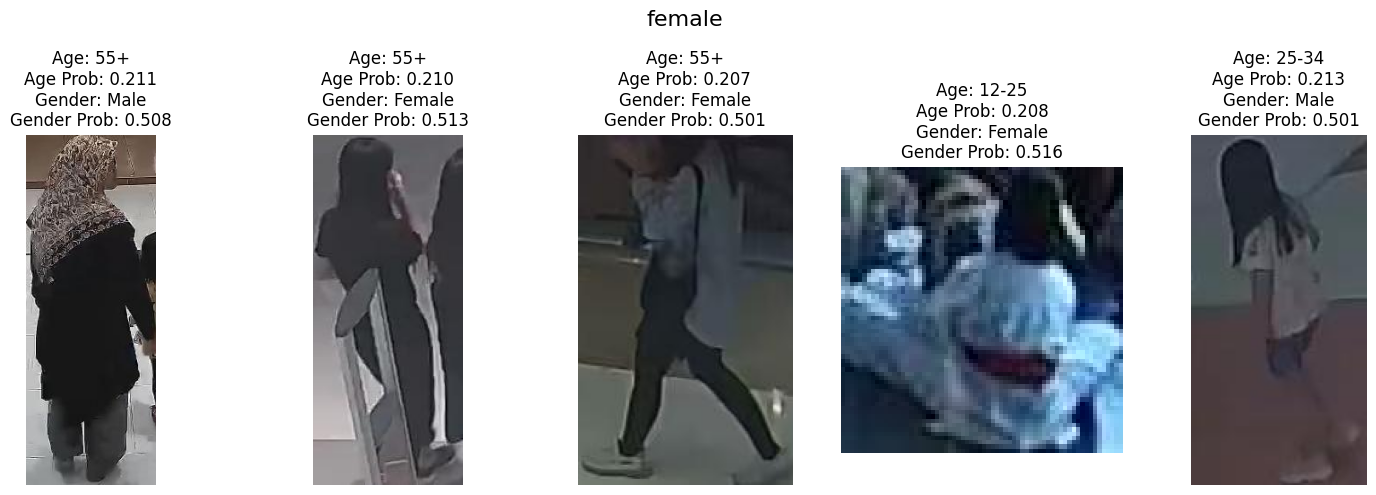

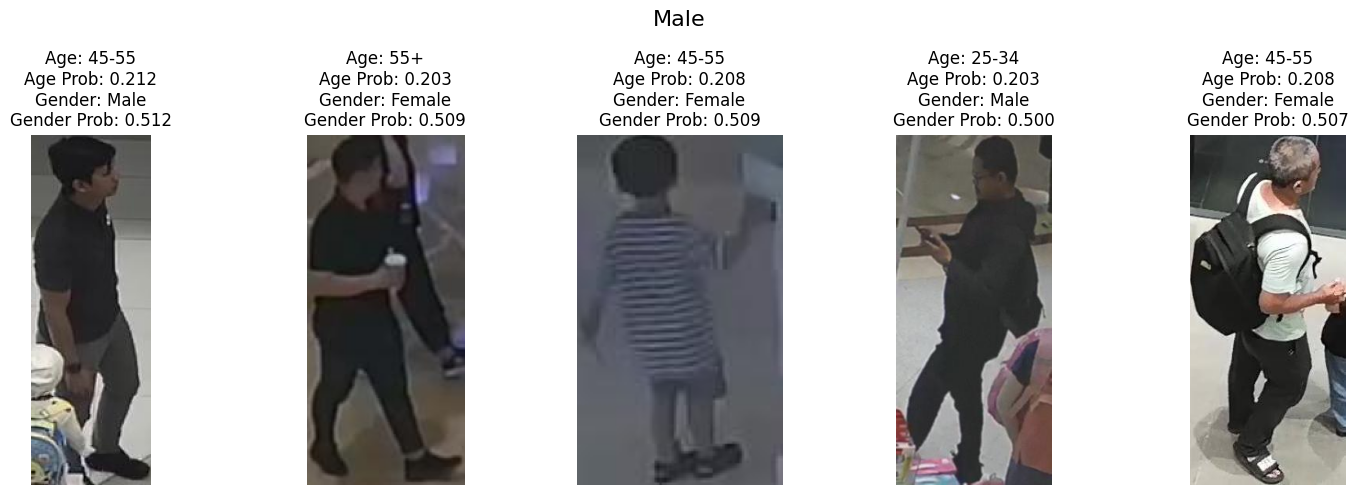

In [61]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple

# Assuming the combined model has been loaded and class names are defined for both age and gender.
# For example:
# model = multi_head_age_model
# age_class_names = ['0-18', '19-29', '30-39', '40-49', '50+']
# gender_class_names = ['Male', 'Female']

def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        age_class_names: List[str],
                        gender_class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: transforms.Compose = None,
                        device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')) -> Tuple[Image.Image, str, float, str, float]:
    # Open image
    img = Image.open(image_path).convert('RGB')

    # Create transformation for image (if one doesn't exist)
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    # Ensure the model is on the target device
    model.to(device)

    # Turn on model evaluation mode
    model.eval()

    with torch.no_grad():
        # Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
        transformed_image = transform(img).unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        age_output, gender_output = model(transformed_image.to(device))

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    age_pred_probs = torch.softmax(age_output, dim=1)
    gender_pred_probs = torch.softmax(gender_output, dim=1)

    # Convert prediction probabilities -> prediction labels
    age_pred_label = torch.argmax(age_pred_probs, dim=1)
    gender_pred_label = torch.argmax(gender_pred_probs, dim=1)

    # Extract prediction labels and probabilities
    age_pred = age_class_names[age_pred_label.item()]
    age_prob = age_pred_probs.max().item()

    gender_pred = gender_class_names[gender_pred_label.item()]
    gender_prob = gender_pred_probs.max().item()

    return img, age_pred, age_prob, gender_pred, gender_prob

def plot_images_horizontally(image_data: List[Tuple[Image.Image, str, float, str, float]], title: str):
    fig, axs = plt.subplots(1, len(image_data), figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    for ax, (img, age_pred, age_prob, gender_pred, gender_prob) in zip(axs, image_data):
        ax.imshow(img)
        ax.set_title(f"Age: {age_pred}\nAge Prob: {age_prob:.3f}\nGender: {gender_pred}\nGender Prob: {gender_prob:.3f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Define the shared folder path
shared_folder_path = "/home/ubuntu/updated_model_training/gen_data/test"

# Define class names for age and gender
age_class_names = ['12-25', '25-34', '34-45', '45-55', '55+']
gender_class_names = ['Male', 'Female']

# Define the model and transformation (assuming `train_transform` is already defined)
model = multi_head_age_model
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Iterate over each subfolder and collect images
for subfolder in os.listdir(shared_folder_path):
    subfolder_path = os.path.join(shared_folder_path, subfolder)
    if os.path.isdir(subfolder_path):
        image_files = [f for f in os.listdir(subfolder_path) if f.endswith((".png", ".jpg", ".bmp"))]
        image_files = image_files[:5]  # Take only the first 5 images
        
        image_data = []
        for image_file in image_files:
            image_path = os.path.join(subfolder_path, image_file)
            img, age_pred, age_prob, gender_pred, gender_prob = pred_and_plot_image(model=model,
                                                                                   image_path=image_path,
                                                                                   age_class_names=age_class_names,
                                                                                   gender_class_names=gender_class_names,
                                                                                   transform=train_transform)
            image_data.append((img, age_pred, age_prob, gender_pred, gender_prob))

        # Plot images horizontally for the current subfolder
        plot_images_horizontally(image_data, title=subfolder)


In [29]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'

# Load the pre-trained MobileViT-V2 model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained MobileViT-V2 model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)

# Define the multi-head model with separate heads for age and gender
class MultiHeadModel(nn.Module):
    def __init__(self, age_model, gender_model):
        super(MultiHeadModel, self).__init__()
        self.age_model = age_model
        self.gender_model = gender_model

    def forward(self, x):
        age_output = self.age_model(x)
        gender_output = self.gender_model(x)
        return age_output, gender_output

# Initialize the new multi-head model
multi_head_model = MultiHeadModel(age_model, gender_model)

# Print the combined model architecture
print(multi_head_model)

# Save the updated model
torch.save(multi_head_model.state_dict(), '/home/ubuntu/multihead_separate.pt')


MultiHeadModel(
  (age_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw)

In [20]:
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'
# Load the pre-trained MobileViT-V2 model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained MobileViT-V2 model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)


<All keys matched successfully>

In [27]:
import torch
import torch.nn as nn
import timm

class MultiHeadModel(nn.Module):
    def __init__(self, model_name, num_age_classes, num_gender_classes):
        super(MultiHeadModel, self).__init__()
        
        # Load the pre-trained MobileViT-V2 model for age classification
        self.age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
        num_in_features_age = self.age_model.head.in_features
        
        # Modify the age model with a custom classifier
        self.age_head = nn.Sequential(
            nn.BatchNorm1d(num_in_features_age),
            nn.Linear(num_in_features_age, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, num_age_classes, bias=False)
        )
        
        # Load the pre-trained MobileViT-V2 model for gender classification
        self.gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)
        num_in_features_gender = self.gender_model.head.in_features
        
        # Modify the gender model with a custom classifier
        self.gender_head = nn.Sequential(
            nn.BatchNorm1d(num_in_features_gender),
            nn.Linear(num_in_features_gender, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, num_gender_classes, bias=False)
        )
        
    def forward(self, x):
        # Forward pass for age classification
        age_features = self.age_model.forward_features(x)
        age_output = self.age_head(age_features)
        
        # Forward pass for gender classification
        gender_features = self.gender_model.forward_features(x)
        gender_output = self.gender_head(gender_features)
        
        return age_output, gender_output

# Instantiate the MultiHeadModel
model_name = 'convnext_atto.d2_in1k'
num_age_classes = 5
num_gender_classes = 2
multi_head_model = MultiHeadModel(model_name, num_age_classes, num_gender_classes)

# Load the pre-trained weights for age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
multi_head_model.age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained weights for gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
multi_head_model.gender_model.load_state_dict(gender_model_state_dict)

# Optionally, move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
multi_head_model.to(device)


RuntimeError: Error(s) in loading state_dict for ConvNeXt:
	Unexpected key(s) in state_dict: "fc.0.weight", "fc.0.bias", "fc.0.running_mean", "fc.0.running_var", "fc.0.num_batches_tracked", "fc.1.weight", "fc.3.weight", "fc.3.bias", "fc.3.running_mean", "fc.3.running_var", "fc.3.num_batches_tracked", "fc.5.weight". 

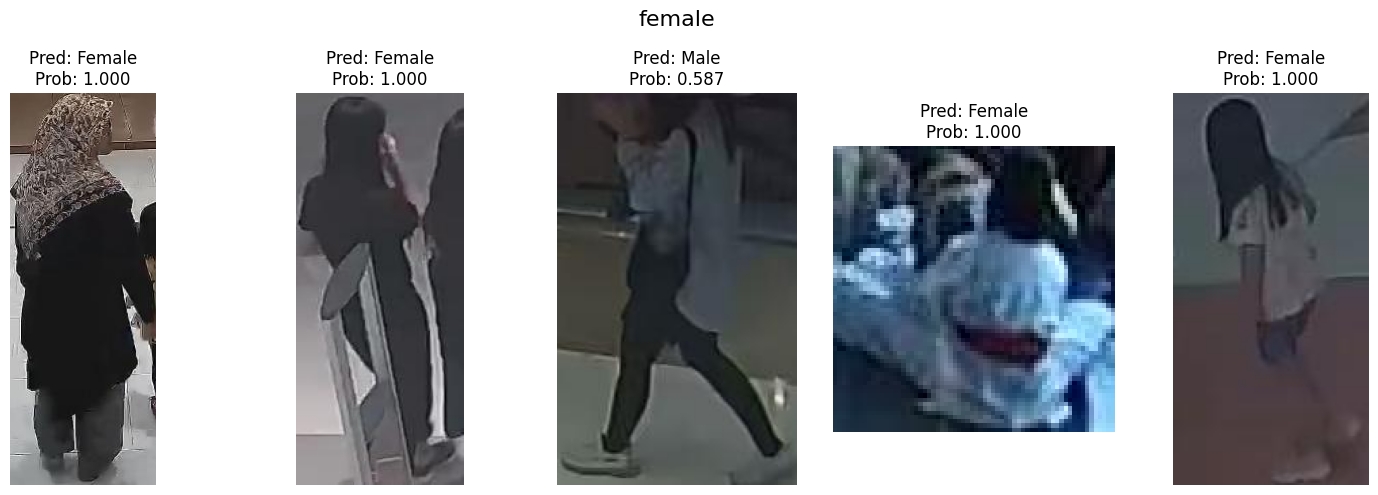

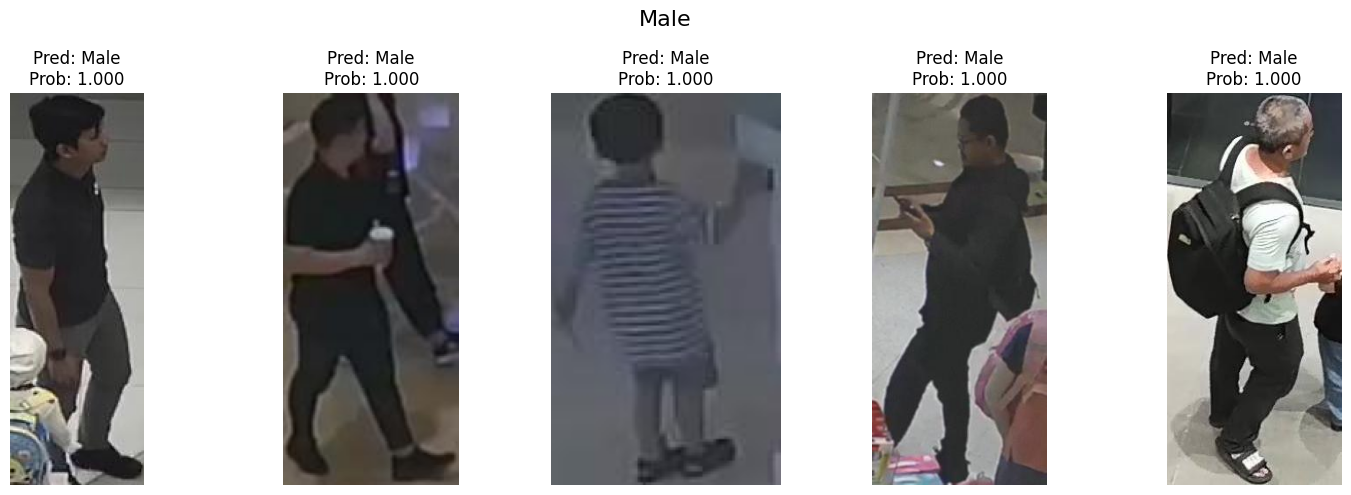

In [22]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple

def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: transforms.Compose = None,
                        device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')) -> Tuple[Image.Image, str, float]:
    # Open image
    img = Image.open(image_path).convert('RGB')

    # Create transformation for image (if one doesn't exist)
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    # Ensure the model is on the target device
    model.to(device)

    # Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
        transformed_image = transform(img).unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(transformed_image.to(device))

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Extract prediction label and probability
    pred_label = class_names[target_image_pred_label.item()]
    pred_prob = target_image_pred_probs.max().item()

    return img, pred_label, pred_prob

def plot_images_horizontally(image_data: List[Tuple[Image.Image, str, float]], title: str):
    fig, axs = plt.subplots(1, len(image_data), figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    for ax, (img, pred_label, pred_prob) in zip(axs, image_data):
        ax.imshow(img)
        ax.set_title(f"Pred: {pred_label}\nProb: {pred_prob:.3f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Define the shared folder path
shared_folder_path = "/home/ubuntu/updated_model_training/gen_data/test"

model=gender_model
class_names = ['Male', 'Female']
# Iterate over each subfolder and collect images
for subfolder in os.listdir(shared_folder_path):
    subfolder_path = os.path.join(shared_folder_path, subfolder)
    if os.path.isdir(subfolder_path):
        image_files = [f for f in os.listdir(subfolder_path) if f.endswith((".png", ".jpg", ".bmp"))]
        image_files = image_files[:5]  # Take only the first 5 images
        
        image_data = []
        for image_file in image_files:
            image_path = os.path.join(subfolder_path, image_file)
            img, pred_label, pred_prob = pred_and_plot_image(model=model,
                                                             image_path=image_path,
                                                             class_names=class_names,
                                                             transform=train_transform)
            image_data.append((img, pred_label, pred_prob))

        # Plot images horizontally for the current subfolder
        plot_images_horizontally(image_data, title=subfolder)


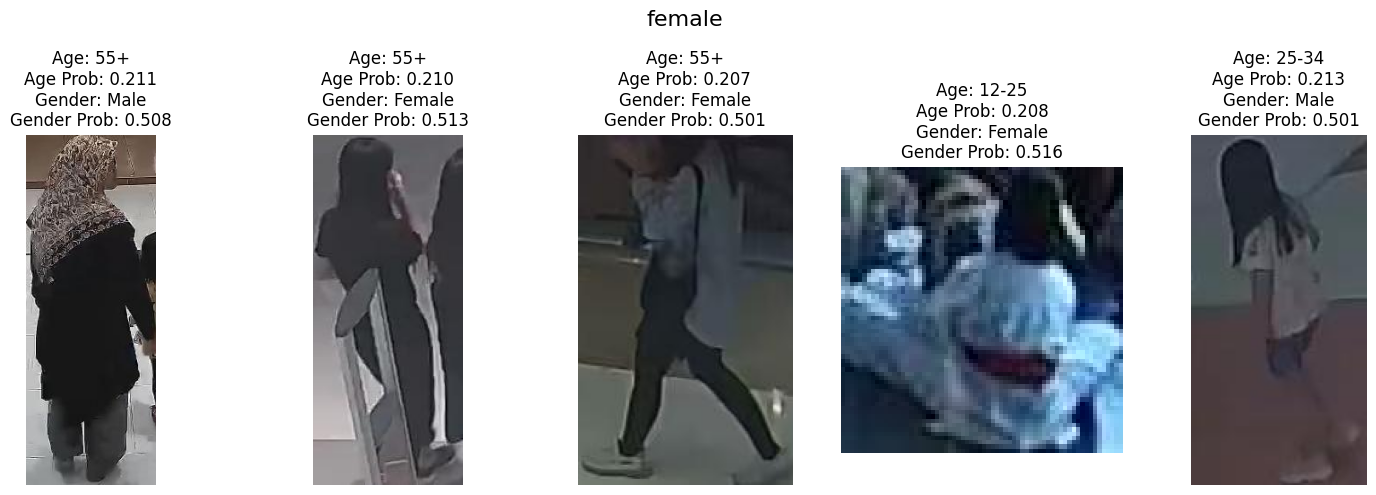

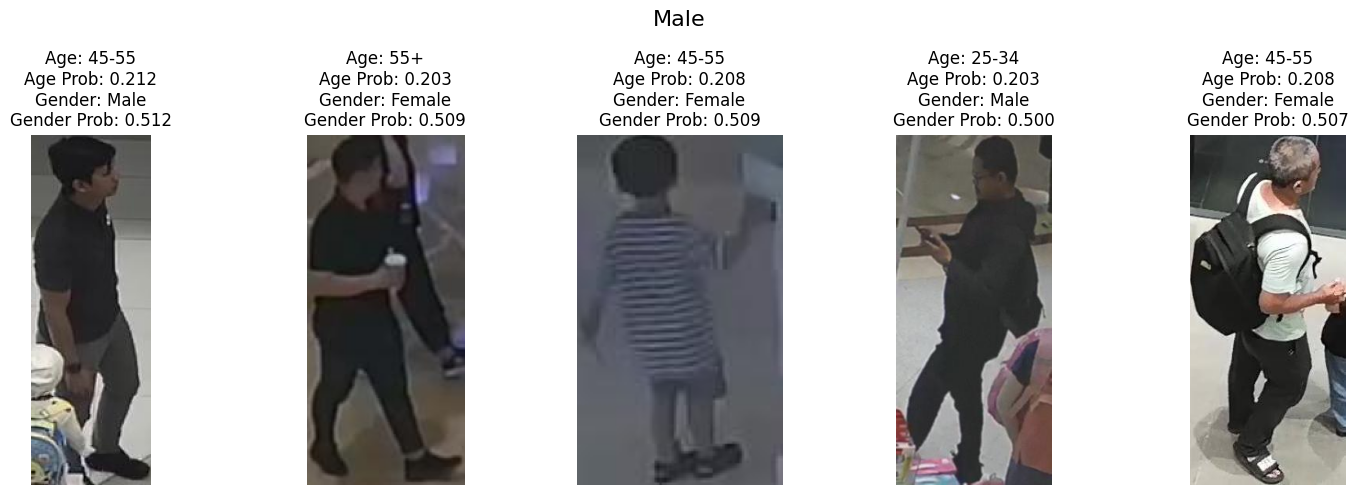

In [46]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple

# Assuming the combined model has been loaded and class names are defined for both age and gender.
# For example:
# model = multi_head_age_model
# age_class_names = ['0-18', '19-29', '30-39', '40-49', '50+']
# gender_class_names = ['Male', 'Female']

def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        age_class_names: List[str],
                        gender_class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: transforms.Compose = None,
                        device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')) -> Tuple[Image.Image, str, float, str, float]:
    # Open image
    img = Image.open(image_path).convert('RGB')

    # Create transformation for image (if one doesn't exist)
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    # Ensure the model is on the target device
    model.to(device)

    # Turn on model evaluation mode
    model.eval()

    with torch.no_grad():
        # Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
        transformed_image = transform(img).unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        age_output, gender_output = model(transformed_image.to(device))

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    age_pred_probs = torch.softmax(age_output, dim=1)
    gender_pred_probs = torch.softmax(gender_output, dim=1)

    # Convert prediction probabilities -> prediction labels
    age_pred_label = torch.argmax(age_pred_probs, dim=1)
    gender_pred_label = torch.argmax(gender_pred_probs, dim=1)

    # Extract prediction labels and probabilities
    age_pred = age_class_names[age_pred_label.item()]
    age_prob = age_pred_probs.max().item()

    gender_pred = gender_class_names[gender_pred_label.item()]
    gender_prob = gender_pred_probs.max().item()

    return img, age_pred, age_prob, gender_pred, gender_prob

def plot_images_horizontally(image_data: List[Tuple[Image.Image, str, float, str, float]], title: str):
    fig, axs = plt.subplots(1, len(image_data), figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    for ax, (img, age_pred, age_prob, gender_pred, gender_prob) in zip(axs, image_data):
        ax.imshow(img)
        ax.set_title(f"Age: {age_pred}\nAge Prob: {age_prob:.3f}\nGender: {gender_pred}\nGender Prob: {gender_prob:.3f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Define the shared folder path
shared_folder_path = "/home/ubuntu/updated_model_training/gen_data/test"

# Define class names for age and gender
age_class_names = ['12-25', '25-34', '34-45', '45-55', '55+']
gender_class_names = ['Male', 'Female']

# Define the model and transformation (assuming `train_transform` is already defined)
model = multi_head_age_model
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Iterate over each subfolder and collect images
for subfolder in os.listdir(shared_folder_path):
    subfolder_path = os.path.join(shared_folder_path, subfolder)
    if os.path.isdir(subfolder_path):
        image_files = [f for f in os.listdir(subfolder_path) if f.endswith((".png", ".jpg", ".bmp"))]
        image_files = image_files[:5]  # Take only the first 5 images
        
        image_data = []
        for image_file in image_files:
            image_path = os.path.join(subfolder_path, image_file)
            img, age_pred, age_prob, gender_pred, gender_prob = pred_and_plot_image(model=model,
                                                                                   image_path=image_path,
                                                                                   age_class_names=age_class_names,
                                                                                   gender_class_names=gender_class_names,
                                                                                   transform=train_transform)
            image_data.append((img, age_pred, age_prob, gender_pred, gender_prob))

        # Plot images horizontally for the current subfolder
        plot_images_horizontally(image_data, title=subfolder)


In [33]:
class MultiHeadModel(nn.Module):
    def __init__(self, age_model, gender_model):
        super(MultiHeadModel, self).__init__()
        self.age_model = age_model
        self.gender_model = gender_model

    def forward(self, x):
        age_output = self.age_model(x)
        gender_output = self.gender_model(x)
        return age_output, gender_output

# Instantiate the MultiHeadModel
suma = MultiHeadModel(age_model, gender_model)

# Load the saved state dictionary
suma.load_state_dict(torch.load('/home/ubuntu/multihead_separate.pt'))


<All keys matched successfully>

In [34]:
print(suma)

MultiHeadModel(
  (age_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw)

In [53]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'

# Load the pre-trained MobileViT-V2 model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Save the state_dict of the age model before adding the gender head
age_model_state_dict_before = age_model.state_dict()

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained MobileViT-V2 model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)

# Define the combined model with two heads
class MultiHeadAgeModel(nn.Module):
    def __init__(self, age_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadAgeModel, self).__init__()
        self.age_model = age_model
        self.age_model.fc = nn.Identity()  # Remove the original classifier

        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )

        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)

        # Gender classification head (initialize with zeros, will load weights later)
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)

    def forward(self, x):
        x = self.age_model.forward_features(x)
        # Perform manual global average pooling
        x = torch.mean(x, dim=[2, 3])
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the new multi-head model
multi_head_age_model = MultiHeadAgeModel(age_model, num_in_features, num_age_classes, num_gender_classes)

# Transfer weights from the pre-trained gender model to the new gender head
with torch.no_grad():
    multi_head_age_model.gender_head.weight.copy_(gender_model.fc[-1].weight)
    if gender_model.fc[-1].bias is not None:
        multi_head_age_model.gender_head.bias.copy_(gender_model.fc[-1].bias)

# Check if the weights were properly copied
print("Gender Head Weight Comparison:")
print("Pre-trained Gender Model Weight:")
print(gender_model.fc[-1].weight)
print("Multi-Head Model Gender Head Weight:")
print(multi_head_age_model.gender_head.weight)

if gender_model.fc[-1].bias is not None:
    print("\nGender Head Bias Comparison:")
    print("Pre-trained Gender Model Bias:")
    print(gender_model.fc[-1].bias)
    print("Multi-Head Model Gender Head Bias:")
    print(multi_head_age_model.gender_head.bias)


print("Pre-trained Age Model Weight:")
print(age_model_state_dict_before['classifier.weight'])

# Print the combined model architecture
print(multi_head_age_model)

# Save the updated model
torch.save(multi_head_age_model.state_dict(), '/home/ubuntu/multihead.pt')


Gender Head Weight Comparison:
Pre-trained Gender Model Weight:
Parameter containing:
tensor([[-0.0312, -0.0167,  0.0092,  ...,  0.0054, -0.0070,  0.0215],
        [ 0.0246,  0.0291,  0.0317,  ..., -0.0179, -0.0080, -0.0122]],
       requires_grad=True)
Multi-Head Model Gender Head Weight:
Parameter containing:
tensor([[-0.0312, -0.0167,  0.0092,  ...,  0.0054, -0.0070,  0.0215],
        [ 0.0246,  0.0291,  0.0317,  ..., -0.0179, -0.0080, -0.0122]],
       requires_grad=True)
Pre-trained Age Model Weight:


KeyError: 'classifier.weight'

In [5]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Define the number of classes for each task
num_age_classes = 5  # Adjust this based on your age classification task
num_gender_classes = 2  # Adjust this based on your gender classification task

# Load the pre-trained MobileViT-V2 model
model = timm.create_model('convnext_atto.d2_in1k', pretrained=True)

# Get the number of input features for the classifier
num_in_features = model.get_classifier().in_features

# Define the new model with two heads
class MultiHeadModel(nn.Module):
    def __init__(self, base_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadModel, self).__init__()
        self.base_model = base_model
        self.base_model.reset_classifier(0)  # Remove the original classifier
        
        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )
        
        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)
        
        # Gender classification head
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)
    
    def forward(self, x):
        x = self.base_model.forward_features(x)
        x = self.base_model.global_pool(x)
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the model with the two heads
multi_head_model = MultiHeadModel(model, num_in_features, num_age_classes, num_gender_classes)

# Print the model architecture
print(multi_head_model)


model.safetensors:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

MultiHeadModel(
  (base_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw

In [7]:
import os

# Specify the directory where you want to create the Python file
directory_path = '/home/ubuntu/'

# Ensure the directory exists, or create it if it doesn't
os.makedirs(directory_path, exist_ok=True)

# Specify the name of the Python file you want to create
file_name = 'data_setup.py'

# Combine the directory path and file name to create the full file path
file_path = os.path.join(directory_path, file_name)

# The content you want to write to the Python file
file_content = """
def setup_data():
    # Your data setup code here

if __name__ == "__main__":
    setup_data()
"""

# Create the file and write the content
with open(file_path, 'w') as file:
    file.write(file_content)
    print(f"Python file '{file_name}' created in '{directory_path}'.")


Python file 'data_setup.py' created in '/home/ubuntu/'.


In [49]:
%%writefile /home/ubuntu/data_setup.py
"""
Contains functionality for creating PyTorch DataLoaders for 
image classification data.
"""
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    age_train_dir: str, 
    age_test_dir: str, 
    gender_train_dir: str,
    gender_test_dir: str,
    transform: transforms.Compose, 
    batch_size: int, 
    num_workers: int=NUM_WORKERS
):
    """Creates training and testing DataLoaders for age and gender classification.

    Takes in training and testing directory paths for age and gender data and turns
    them into PyTorch Datasets and then into PyTorch DataLoaders.

    Args:
        age_train_dir: Path to age training directory.
        age_test_dir: Path to age testing directory.
        gender_train_dir: Path to gender training directory.
        gender_test_dir: Path to gender testing directory.
        transform: torchvision transforms to perform on training and testing data.
        batch_size: Number of samples per batch in each of the DataLoaders.
        num_workers: An integer for number of workers per DataLoader.

    Returns:
        A tuple of (age_train_dataloader, age_test_dataloader, gender_train_dataloader, gender_test_dataloader, age_class_names, gender_class_names).
        Example usage:
            age_train_dl, age_test_dl, gender_train_dl, gender_test_dl, age_classes, gender_classes = \
                create_dataloaders(
                    age_train_dir="path/to/age_train_dir",
                    age_test_dir="path/to/age_test_dir",
                    gender_train_dir="path/to/gender_train_dir",
                    gender_test_dir="path/to/gender_test_dir",
                    transform=some_transform,
                    batch_size=32,
                    num_workers=4
                )
    """
    # Use ImageFolder to create dataset(s) for age classification
    age_train_data = datasets.ImageFolder(age_train_dir, transform=transform)
    age_test_data = datasets.ImageFolder(age_test_dir, transform=transform)

    # Use ImageFolder to create dataset(s) for gender classification
    gender_train_data = datasets.ImageFolder(gender_train_dir, transform=transform)
    gender_test_data = datasets.ImageFolder(gender_test_dir, transform=transform)

    # Get class names
    age_class_names = age_train_data.classes
    gender_class_names = gender_train_data.classes

    # Turn images into data loaders for age classification
    age_train_dataloader = DataLoader(
        age_train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    age_test_dataloader = DataLoader(
        age_test_data,
        batch_size=batch_size,
        shuffle=False, # don't need to shuffle test data
        num_workers=num_workers,
        pin_memory=True,
    )

    # Turn images into data loaders for gender classification
    gender_train_dataloader = DataLoader(
        gender_train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    gender_test_dataloader = DataLoader(
        gender_test_data,
        batch_size=batch_size,
        shuffle=False, # don't need to shuffle test data
        num_workers=num_workers,
        pin_memory=True,
    )

    return age_train_dataloader, age_test_dataloader, gender_train_dataloader, gender_test_dataloader, age_class_names, gender_class_names


Overwriting /home/ubuntu/data_setup.py


In [54]:
import sys
sys.path.append('/home/ubuntu/')

import data_setup
import engine_1 
from data_setup import create_dataloaders
from engine_1 import train_age_head, train_gender_head


In [13]:
from data_setup import create_dataloaders
from torchvision import transforms

# Define your transforms
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Paths to your datasets
age_train_dir = "/home/ubuntu/updated_model_training/age_aug/train"
age_test_dir = "/home/ubuntu/updated_model_training/age_aug/valid"
gender_train_dir = "/home/ubuntu/updated_model_training/gen_data/train"
gender_test_dir = "/home/ubuntu/updated_model_training/gen_data/valid"

# Create the dataloaders
age_train_dl, age_test_dl, gender_train_dl, gender_test_dl, age_classes, gender_classes = create_dataloaders(
    age_train_dir=age_train_dir,
    age_test_dir=age_test_dir,
    gender_train_dir=gender_train_dir,
    gender_test_dir=gender_test_dir,
    transform=data_transform,
    batch_size=32
)

# Now you can use the dataloaders in your training loop


In [14]:
age_train_dl, age_test_dl, gender_train_dl, gender_test_dl, age_classes, gender_classes

(<torch.utils.data.dataloader.DataLoader at 0x7f5cff05b7c0>,
 ['12-25', '25-34', '35-44', '45-54', 'above55'],
 ['Male', 'female'])

In [56]:
%%writefile /home/ubuntu/engine_1.py
"""
Contains functionality for training and evaluating
age and gender classification models separately.
"""
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Dict, Tuple

def train_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.CrossEntropyLoss,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    head: str
) -> Dict[str, float]:
    """Trains a PyTorch model for a single epoch.

    Args:
        model: A PyTorch model to be trained.
        dataloader: A DataLoader for training data.
        criterion: Loss function.
        optimizer: Optimizer.
        device: Device to perform training on.
        head: 'age' or 'gender' to specify which head to train.

    Returns:
        A dictionary with keys 'train_loss' and 'train_acc' containing the loss and accuracy for the epoch.
    """
    model.train()
    train_loss, correct = 0, 0
    total = 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        if head == 'age':
            outputs, _ = model(inputs)
        else:
            _, outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss /= total
    train_acc = correct / total

    return {'train_loss': train_loss, 'train_acc': train_acc}

def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.CrossEntropyLoss,
    device: torch.device,
    head: str
) -> Dict[str, float]:
    """Evaluates a PyTorch model.

    Args:
        model: A PyTorch model to be evaluated.
        dataloader: A DataLoader for validation or test data.
        criterion: Loss function.
        device: Device to perform evaluation on.
        head: 'age' or 'gender' to specify which head to evaluate.

    Returns:
        A dictionary with keys 'val_loss' and 'val_acc' containing the loss and accuracy for the evaluation.
    """
    model.eval()
    val_loss, correct = 0, 0
    total = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            if head == 'age':
                outputs, _ = model(inputs)
            else:
                _, outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_loss /= total
    val_acc = correct / total

    return {'val_loss': val_loss, 'val_acc': val_acc}

def train_and_evaluate(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    criterion: nn.CrossEntropyLoss,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    device: torch.device,
    head: str
) -> Tuple[Dict[str, float], Dict[str, float]]:
    """Trains and evaluates a PyTorch model.

    Args:
        model: A PyTorch model to be trained and evaluated.
        train_dataloader: DataLoader for training data.
        val_dataloader: DataLoader for validation data.
        criterion: Loss function.
        optimizer: Optimizer.
        epochs: Number of epochs to train for.
        device: Device to perform training and evaluation on.
        head: 'age' or 'gender' to specify which head to train and evaluate.

    Returns:
        A tuple containing two dictionaries:
            - Train results with keys 'train_loss' and 'train_acc'
            - Validation results with keys 'val_loss' and 'val_acc'
    """
    for epoch in range(epochs):
        train_results = train_model(
            model=model,
            dataloader=train_dataloader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            head=head
        )

        val_results = evaluate_model(
            model=model,
            dataloader=val_dataloader,
            criterion=criterion,
            device=device,
            head=head
        )

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_results['train_loss']:.4f}, Train Acc: {train_results['train_acc']:.4f}")
        print(f"Val Loss: {val_results['val_loss']:.4f}, Val Acc: {val_results['val_acc']:.4f}")

    return train_results, val_results

def train_age_head(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    epochs: int,
    device: torch.device
) -> Tuple[Dict[str, float], Dict[str, float]]:
    """Trains the age classification head of the multi-head model.

    Args:
        model: A PyTorch model with an age classification head.
        train_dataloader: DataLoader for age training data.
        val_dataloader: DataLoader for age validation data.
        epochs: Number of epochs to train for.
        device: Device to perform training and evaluation on.

    Returns:
        A tuple containing the training and validation results.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.age_head.parameters(), lr=1e-4)
    
    return train_and_evaluate(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs,
        device=device,
        head='age'
    )

def train_gender_head(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    epochs: int,
    device: torch.device
) -> Tuple[Dict[str, float], Dict[str, float]]:
    """Trains the gender classification head of the multi-head model.

    Args:
        model: A PyTorch model with a gender classification head.
        train_dataloader: DataLoader for gender training data.
        val_dataloader: DataLoader for gender validation data.
        epochs: Number of epochs to train for.
        device: Device to perform training and evaluation on.

    Returns:
        A tuple containing the training and validation results.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.gender_head.parameters(), lr=1e-4)
    
    return train_and_evaluate(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs,
        device=device,
        head='gender'
    )


Overwriting /home/ubuntu/engine_1.py


In [57]:
import torch
import torch.nn as nn
from torchvision import transforms
from timm import create_model
import sys
sys.path.append('/home/ubuntu/')

import data_setup
import engine_1 
from data_setup import create_dataloaders
from engine_1 import train_age_head, train_gender_head


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Directories for training and testing data
age_train_dir = "/home/ubuntu/updated_model_training/age_aug/train"
age_test_dir = "/home/ubuntu/updated_model_training/age_aug/valid"
gender_train_dir = "/home/ubuntu/updated_model_training/gen_data/train"
gender_test_dir = "/home/ubuntu/updated_model_training/gen_data/valid"
# Data transformation
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create DataLoaders
batch_size = 32
age_train_dataloader, age_test_dataloader, gender_train_dataloader, gender_test_dataloader, age_classes, gender_classes = create_dataloaders(
    age_train_dir=age_train_dir,
    age_test_dir=age_test_dir,
    gender_train_dir=gender_train_dir,
    gender_test_dir=gender_test_dir,
    transform=data_transform,
    batch_size=batch_size
)

# Load pre-trained model
model = create_model('convnext_atto.d2_in1k', pretrained=True)

# Get number of input features for the classifier
num_in_features = model.get_classifier().in_features

# Define MultiHeadModel class (the same as in your initial code)
class MultiHeadModel(nn.Module):
    def __init__(self, base_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadModel, self).__init__()
        self.base_model = base_model
        self.base_model.reset_classifier(0)  # Remove the original classifier
        
        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )
        
        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)
        
        # Gender classification head
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)
    
    def forward(self, x):
        x = self.base_model.forward_features(x)
        x = self.base_model.global_pool(x)
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the model with the two heads
num_age_classes = len(age_classes)
num_gender_classes = len(gender_classes)
multi_head_model = MultiHeadModel(model, num_in_features, num_age_classes, num_gender_classes).to(device)

# Train the age head
epochs = 10

print("Training age head...")
train_age_head_results, val_age_head_results = train_age_head(
    model=multi_head_model,
    train_dataloader=age_train_dataloader,
    val_dataloader=age_test_dataloader,
    epochs=epochs,
    device=device
)

# Train the gender head
print("Training gender head...")
train_gender_head_results, val_gender_head_results = train_gender_head(
    model=multi_head_model,
    train_dataloader=gender_train_dataloader,
    val_dataloader=gender_test_dataloader,
    epochs=epochs,
    device=device
)


Training age head...


RuntimeError: mat1 and mat2 shapes cannot be multiplied (21504x224 and 512x5)

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
import timm
from torchvision import datasets
from tqdm import tqdm

class MultiHeadModel(nn.Module):
    def __init__(self, base_model, num_in_features, num_age_classes, num_gender_classes):
        super(MultiHeadModel, self).__init__()
        self.base_model = base_model
        self.base_model.reset_classifier(0)  # Remove the original classifier
        
        # Shared layers before the heads
        self.shared_fc = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4)
        )
        
        # Age classification head
        self.age_head = nn.Linear(512, num_age_classes, bias=False)
        
        # Gender classification head
        self.gender_head = nn.Linear(512, num_gender_classes, bias=False)
    
    def forward(self, x):
        x = self.base_model.forward_features(x)
        # Perform global average pooling manually
        x = torch.mean(x, dim=[2, 3])  # Assuming input size [batch_size, channels, height, width]
        x = self.shared_fc(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output


# Define function for creating dataloaders
def create_dataloaders(
    age_train_dir: str, 
    age_test_dir: str, 
    gender_train_dir: str,
    gender_test_dir: str,
    transform: transforms.Compose, 
    batch_size: int, 
    num_workers: int=2
):
    #"""Creates training and testing DataLoaders for age and gender classification."""
    # Use ImageFolder to create dataset(s) for age classification
    age_train_data = datasets.ImageFolder(age_train_dir, transform=transform)
    age_test_data = datasets.ImageFolder(age_test_dir, transform=transform)

    # Use ImageFolder to create dataset(s) for gender classification
    gender_train_data = datasets.ImageFolder(gender_train_dir, transform=transform)
    gender_test_data = datasets.ImageFolder(gender_test_dir, transform=transform)

    # Get class names
    age_class_names = age_train_data.classes
    gender_class_names = gender_train_data.classes

    # Turn images into data loaders for age classification
    age_train_dataloader = DataLoader(
        age_train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    age_test_dataloader = DataLoader(
        age_test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    # Turn images into data loaders for gender classification
    gender_train_dataloader = DataLoader(
        gender_train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    gender_test_dataloader = DataLoader(
        gender_test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return age_train_dataloader, age_test_dataloader, gender_train_dataloader, gender_test_dataloader, age_class_names, gender_class_names

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Define the number of classes for each task
num_age_classes = 5
num_gender_classes = 2

# Load the pre-trained MobileViT-V2 model
model = timm.create_model('convnext_atto.d2_in1k', pretrained=True)

# Get the number of input features for the classifier
num_in_features = model.head.in_features

# Initialize the multi-head model
multi_head_model = MultiHeadModel(model, num_in_features, num_age_classes, num_gender_classes)
multi_head_model.to(device)

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define paths to your datasets
age_train_dir = "/home/ubuntu/updated_model_training/age_aug/train"
age_test_dir = "/home/ubuntu/updated_model_training/age_aug/valid"
gender_train_dir = "/home/ubuntu/updated_model_training/gen_data/train"
gender_test_dir = "/home/ubuntu/updated_model_training/gen_data/valid"

# Create dataloaders
age_train_dataloader, age_test_dataloader, gender_train_dataloader, gender_test_dataloader, age_class_names, gender_class_names = create_dataloaders(
    age_train_dir=age_train_dir,
    age_test_dir=age_test_dir,
    gender_train_dir=gender_train_dir,
    gender_test_dir=gender_test_dir,
    transform=transform,
    batch_size=32
)

# Define optimizer and loss function for the age head
age_optimizer = optim.Adam(multi_head_model.age_head.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Function for training the age head
def train_age_head(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for images, labels in tqdm(dataloader, desc="Training Age Head"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        age_output, _ = model(images)
        _, predicted = torch.max(age_output, 1)
        total_preds += labels.size(0)
        correct_preds += (predicted == labels).sum().item()

        loss = criterion(age_output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    accuracy = correct_preds / total_preds * 100
    return epoch_loss, accuracy

# Function for evaluating the age head
def evaluate_age_head(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating Age Head"):
            images, labels = images.to(device), labels.to(device)

            age_output, _ = model(images)
            _, predicted = torch.max(age_output, 1)
            total_preds += labels.size(0)
            correct_preds += (predicted == labels).sum().item()

            loss = criterion(age_output, labels)
            running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    accuracy = correct_preds / total_preds * 100
    return epoch_loss, accuracy

# Train the age head
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_accuracy = train_age_head(multi_head_model, age_train_dataloader, age_optimizer, criterion, device)
    print(f"Epoch {epoch+    1}/{num_epochs}, Age Train Loss: {train_loss:.4f}, Age Train Accuracy: {train_accuracy:.2f}%")
    
# Define optimizer and loss function for the gender head
gender_optimizer = optim.Adam(multi_head_model.gender_head.parameters(), lr=0.001)

# Function for training the gender head
def train_gender_head(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for images, labels in tqdm(dataloader, desc="Training Gender Head"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        _, gender_output = model(images)
        _, predicted = torch.max(gender_output, 1)
        total_preds += labels.size(0)
        correct_preds += (predicted == labels).sum().item()

        loss = criterion(gender_output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    accuracy = correct_preds / total_preds * 100
    return epoch_loss, accuracy

# Function for evaluating the gender head
def evaluate_gender_head(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating Gender Head"):
            images, labels = images.to(device), labels.to(device)

            _, gender_output = model(images)
            _, predicted = torch.max(gender_output, 1)
            total_preds += labels.size(0)
            correct_preds += (predicted == labels).sum().item()

            loss = criterion(gender_output, labels)
            running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader)
    accuracy = correct_preds / total_preds * 100
    return epoch_loss, accuracy

# Train the gender head
num_epochs_gender = 5

for epoch in range(num_epochs_gender):
    train_loss_gender, train_accuracy_gender = train_gender_head(multi_head_model, gender_train_dataloader, gender_optimizer, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs_gender}, Gender Train Loss: {train_loss_gender:.4f}, Gender Train Accuracy: {train_accuracy_gender:.2f}%")
    
    test_loss_gender, test_accuracy_gender = evaluate_gender_head(multi_head_model, gender_test_dataloader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs_gender}, Gender Test Loss: {test_loss_gender:.4f}, Gender Test Accuracy: {test_accuracy_gender:.2f}%")



Training Age Head: 100%|██████████████████████████████████████████████████████████████| 782/782 [01:34<00:00,  8.29it/s]


Epoch 1/5, Age Train Loss: 1.5593, Age Train Accuracy: 30.53%


Training Age Head: 100%|██████████████████████████████████████████████████████████████| 782/782 [01:34<00:00,  8.28it/s]


Epoch 2/5, Age Train Loss: 1.5075, Age Train Accuracy: 34.22%


Training Age Head: 100%|██████████████████████████████████████████████████████████████| 782/782 [01:34<00:00,  8.26it/s]


...

Epoch 4/5, Gender Test Loss: 0.5757, Gender Test Accuracy: 70.43%


Training Gender Head: 100%|█████████████████████████████████████████████████████████| 1000/1000 [02:01<00:00,  8.25it/s]


Epoch 5/5, Gender Train Loss: 0.6097, Gender Train Accuracy: 67.21%


Evaluating Gender Head: 100%|█████████████████████████████████████████████████████████| 188/188 [00:09<00:00, 20.42it/s]

Epoch 5/5, Gender Test Loss: 0.5791, Gender Test Accuracy: 69.13%


/home/ubuntu/.local/lib/python3.8/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


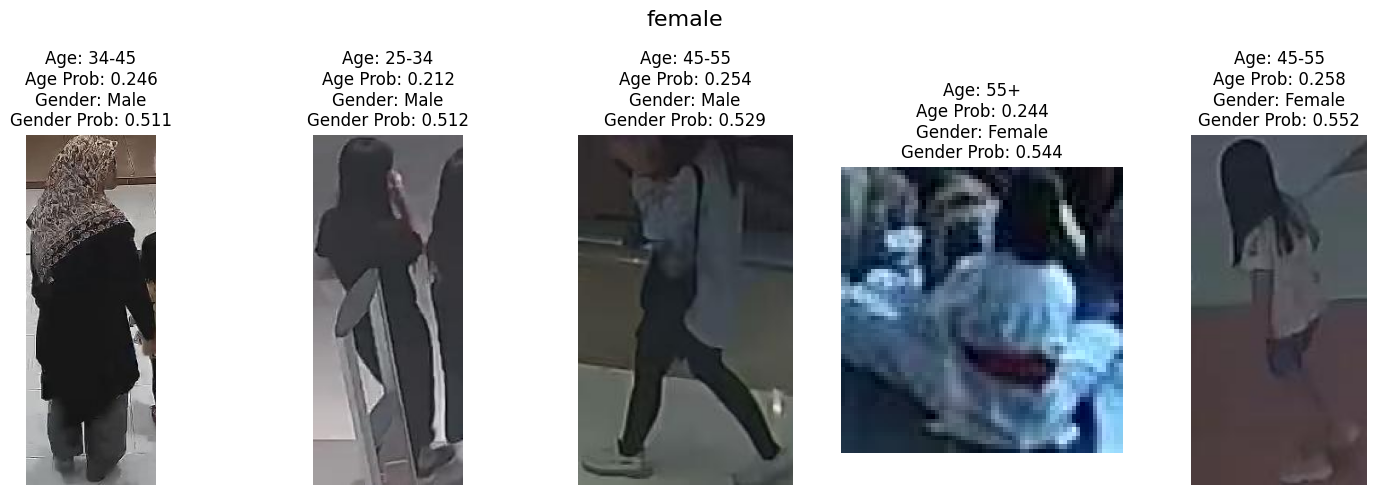

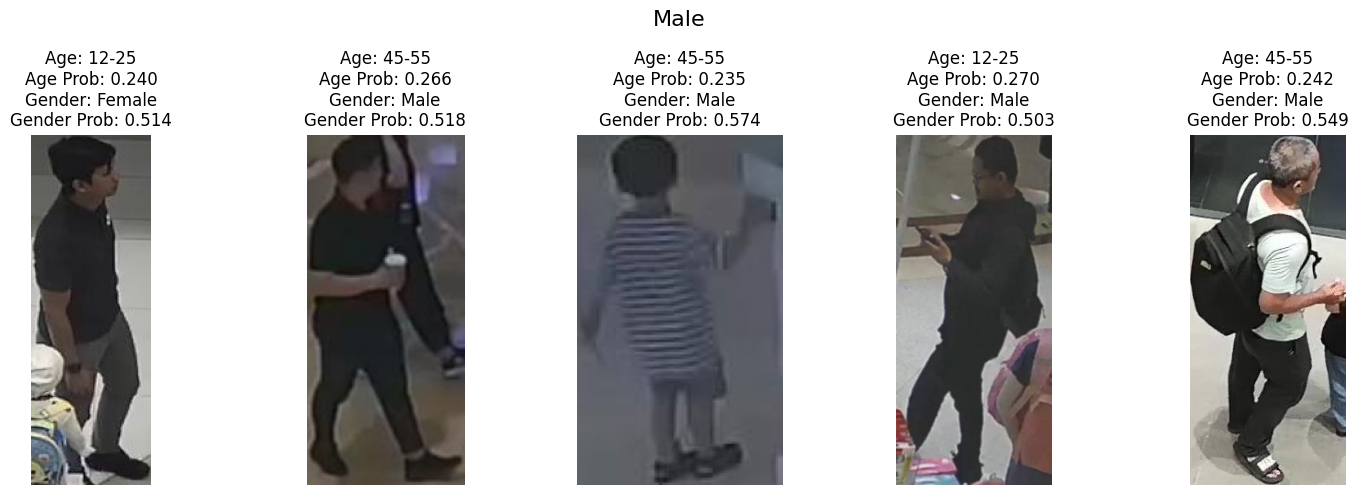

In [33]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple

# Assuming the combined model has been loaded and class names are defined for both age and gender.
# For example:
# model = multi_head_age_model
# age_class_names = ['0-18', '19-29', '30-39', '40-49', '50+']
# gender_class_names = ['Male', 'Female']

def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        age_class_names: List[str],
                        gender_class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: transforms.Compose = None,
                        device: torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')) -> Tuple[Image.Image, str, float, str, float]:
    # Open image
    img = Image.open(image_path).convert('RGB')

    # Create transformation for image (if one doesn't exist)
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
        ])

    # Ensure the model is on the target device
    model.to(device)

    # Turn on model evaluation mode
    model.eval()

    with torch.no_grad():
        # Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
        transformed_image = transform(img).unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        age_output, gender_output = model(transformed_image.to(device))

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    age_pred_probs = torch.softmax(age_output, dim=1)
    gender_pred_probs = torch.softmax(gender_output, dim=1)

    # Convert prediction probabilities -> prediction labels
    age_pred_label = torch.argmax(age_pred_probs, dim=1)
    gender_pred_label = torch.argmax(gender_pred_probs, dim=1)

    # Extract prediction labels and probabilities
    age_pred = age_class_names[age_pred_label.item()]
    age_prob = age_pred_probs.max().item()

    gender_pred = gender_class_names[gender_pred_label.item()]
    gender_prob = gender_pred_probs.max().item()

    return img, age_pred, age_prob, gender_pred, gender_prob

def plot_images_horizontally(image_data: List[Tuple[Image.Image, str, float, str, float]], title: str):
    fig, axs = plt.subplots(1, len(image_data), figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    for ax, (img, age_pred, age_prob, gender_pred, gender_prob) in zip(axs, image_data):
        ax.imshow(img)
        ax.set_title(f"Age: {age_pred}\nAge Prob: {age_prob:.3f}\nGender: {gender_pred}\nGender Prob: {gender_prob:.3f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Define the shared folder path
shared_folder_path = "/home/ubuntu/updated_model_training/gen_data/test"

# Define class names for age and gender
age_class_names = ['12-25', '25-34', '34-45', '45-55', '55+']
gender_class_names = ['Male', 'Female']

# Define the model and transformation (assuming `train_transform` is already defined)
model = multi_head_model
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Iterate over each subfolder and collect images
for subfolder in os.listdir(shared_folder_path):
    subfolder_path = os.path.join(shared_folder_path, subfolder)
    if os.path.isdir(subfolder_path):
        image_files = [f for f in os.listdir(subfolder_path) if f.endswith((".png", ".jpg", ".bmp"))]
        image_files = image_files[:5]  # Take only the first 5 images
        
        image_data = []
        for image_file in image_files:
            image_path = os.path.join(subfolder_path, image_file)
            img, age_pred, age_prob, gender_pred, gender_prob = pred_and_plot_image(model=model,
                                                                                   image_path=image_path,
                                                                                   age_class_names=age_class_names,
                                                                                   gender_class_names=gender_class_names,
                                                                                   transform=train_transform)
            image_data.append((img, age_pred, age_prob, gender_pred, gender_prob))

        # Plot images horizontally for the current subfolder
        plot_images_horizontally(image_data, title=subfolder)


In [32]:
multi_head_model

MultiHeadModel(
  (base_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw

/tmp/ipykernel_3044/2375863513.py:113: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 2, 2)


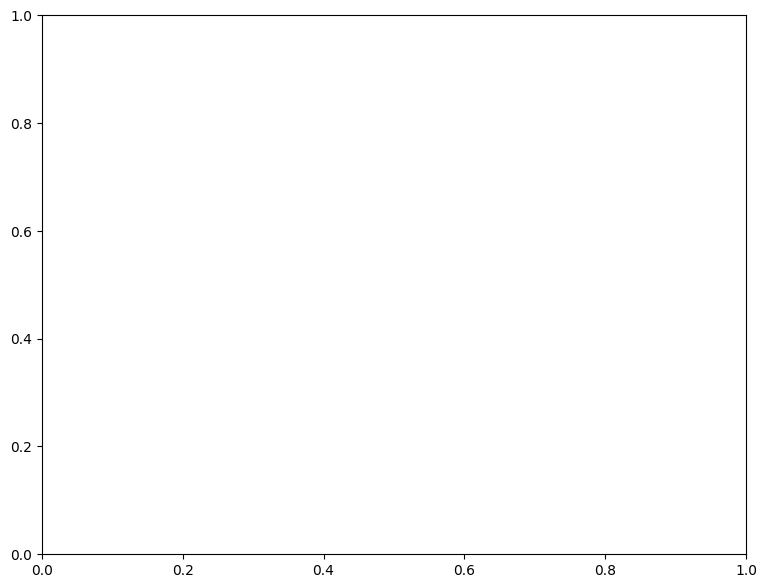

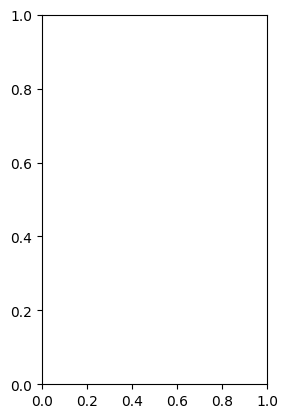

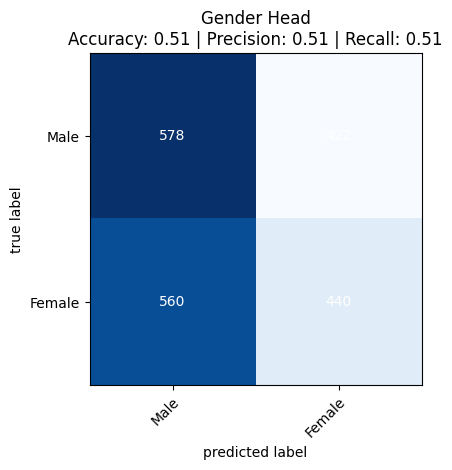

Age Head Metrics:
Accuracy: 0.18
Precision: 0.18
Recall: 0.18

Gender Head Metrics:
Accuracy: 0.51
Precision: 0.51
Recall: 0.51


In [32]:
import os
import torch
import torch.nn as nn
import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Define the transformations for age and gender test datasets
transform_age = transforms.Compose([
    transforms.Resize((224, 224), interpolation=2),
    transforms.ToTensor(),
])

transform_gender = transforms.Compose([
    transforms.Resize((224, 224), interpolation=2),
    transforms.ToTensor(),
])

# Load the test datasets using DataLoader
test_dataset_age = datasets.ImageFolder(root='/home/ubuntu/updated_model_training/age_aug/test', transform=transform_age)
testloader_age = DataLoader(test_dataset_age, batch_size=32, shuffle=False, num_workers=2)

test_dataset_gender = datasets.ImageFolder(root='/home/ubuntu/updated_model_training/gen_data/test', transform=transform_gender)
testloader_gender = DataLoader(test_dataset_gender, batch_size=32, shuffle=False, num_workers=2)

# Define your device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load your model
num_classes_age = 5  # 5 classes for age ('12-25', '25-34', '34-45', '45-55', '55+')
num_classes_gender = 2  # 2 classes for gender ('Male', 'Female')
# Modify with your model initialization
model=multi_head_model
model.to(device)
model.eval()

# Initialize empty lists to store true and predicted labels for age and gender
y_true_age = []
y_pred_age = []
y_true_gender = []
y_pred_gender = []

# Iterate over the age test data
for inputs, labels in testloader_age:
    inputs = inputs.to(device)  # Move data to the device (GPU or CPU)
    with torch.no_grad():
        age_output, _ = model(inputs)  # Get outputs from the age head
    
    _, age_predicted = torch.max(age_output, 1)  # Get predicted class labels for age
    y_pred_age.extend(age_predicted.cpu().numpy())
    y_true_age.extend(labels.cpu().numpy())

# Iterate over the gender test data
for inputs, labels in testloader_gender:
    inputs = inputs.to(device)  # Move data to the device (GPU or CPU)
    with torch.no_grad():
        _, gender_output = model(inputs)  # Get outputs from the gender head
    
    _, gender_predicted = torch.max(gender_output, 1)  # Get predicted class labels for gender
    y_pred_gender.extend(gender_predicted.cpu().numpy())
    y_true_gender.extend(labels.cpu().numpy())

# Define class labels for age and gender
age_classes = ['12-25', '25-34', '34-45', '45-55', '55+']
gender_classes = ['Male', 'Female']

# Build confusion matrices using torchmetrics for age and gender
confmat_age = ConfusionMatrix(num_classes=num_classes_age, task='multiclass')
confmat_age_tensor = confmat_age(torch.tensor(y_pred_age), torch.tensor(y_true_age))

confmat_gender = ConfusionMatrix(num_classes=num_classes_gender, task='multiclass')
confmat_gender_tensor = confmat_gender(torch.tensor(y_pred_gender), torch.tensor(y_true_gender))

# Calculate accuracy, precision, and recall for age
accuracy_age = Accuracy(task='multiclass', num_classes=num_classes_age)
accuracy_score_age = accuracy_age(torch.tensor(y_pred_age), torch.tensor(y_true_age))

precision_age = Precision(task='multiclass', average='macro', num_classes=num_classes_age)
precision_score_age = precision_age(torch.tensor(y_pred_age), torch.tensor(y_true_age))

recall_age = Recall(task='multiclass', average='macro', num_classes=num_classes_age)
recall_score_age = recall_age(torch.tensor(y_pred_age), torch.tensor(y_true_age))

# Calculate accuracy, precision, and recall for gender
accuracy_gender = Accuracy(task='multiclass', num_classes=num_classes_gender)
accuracy_score_gender = accuracy_gender(torch.tensor(y_pred_gender), torch.tensor(y_true_gender))

precision_gender = Precision(task='multiclass', average='macro', num_classes=num_classes_gender)
precision_score_gender = precision_gender(torch.tensor(y_pred_gender), torch.tensor(y_true_gender))

recall_gender = Recall(task='multiclass', average='macro', num_classes=num_classes_gender)
recall_score_gender = recall_gender(torch.tensor(y_pred_gender), torch.tensor(y_true_gender))

# Plot the confusion matrices for age and gender separately
plt.figure(figsize=(20, 7))

# Plot confusion matrix for age
plt.subplot(1, 2, 2)
plot_confusion_matrix(
    confmat_age_tensor.cpu().numpy(),
    class_names=age_classes
)
plt.title(f'Age Head\nAccuracy: {accuracy_score_age:.2f} | Precision: {precision_score_age:.2f} | Recall: {recall_score_age:.2f}')

# Plot confusion matrix for gender
plt.subplot(1, 2, 2)
plot_confusion_matrix(
    confmat_gender_tensor.cpu().numpy(),
    class_names=gender_classes
)
plt.title(f'Gender Head\nAccuracy: {accuracy_score_gender:.2f} | Precision: {precision_score_gender:.2f} | Recall: {recall_score_gender:.2f}')

plt.tight_layout()
plt.show()

# Print the accuracy, precision, and recall scores for age and gender
print('Age Head Metrics:')
print(f'Accuracy: {accuracy_score_age:.2f}')
print(f'Precision: {precision_score_age:.2f}')
print(f'Recall: {recall_score_age:.2f}')
print('\nGender Head Metrics:')
print(f'Accuracy: {accuracy_score_gender:.2f}')
print(f'Precision: {precision_score_gender:.2f}')
print(f'Recall: {recall_score_gender:.2f}')



Text(0.5, 1.0, 'Age Head\nAccuracy: 0.18 | Precision: 0.18 | Recall: 0.18')

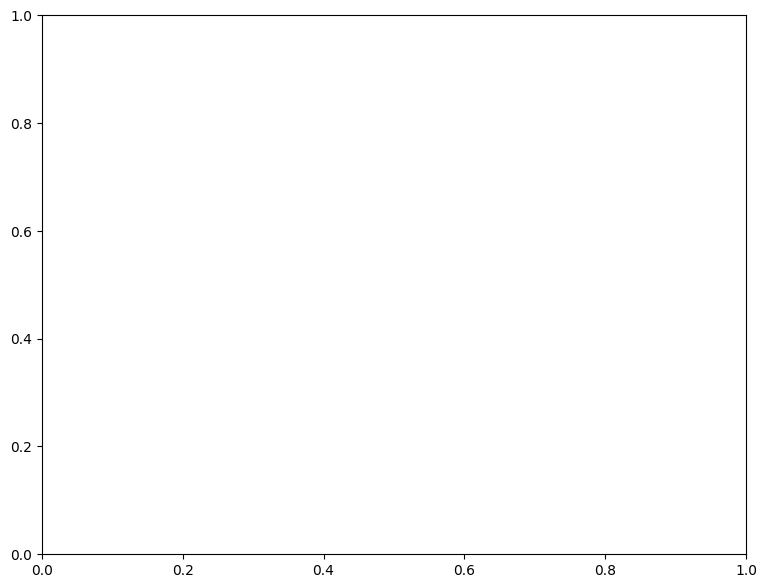

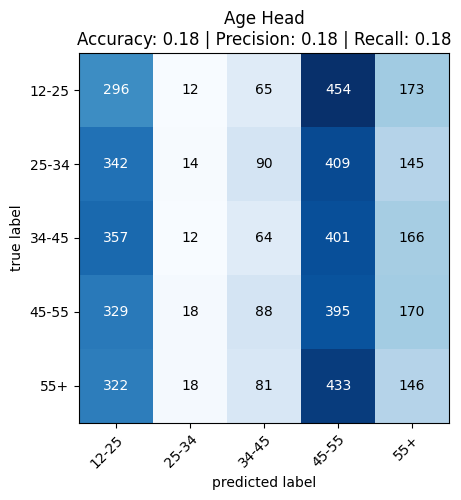

In [30]:
plt.figure(figsize=(20, 7))

# Plot confusion matrix for age
plt.subplot(1, 2, 1)
plot_confusion_matrix(
    confmat_age_tensor.cpu().numpy(),
    class_names=age_classes
)
plt.title(f'Age Head\nAccuracy: {accuracy_score_age:.2f} | Precision: {precision_score_age:.2f} | Recall: {recall_score_age:.2f}')


In [1]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'

# Load the pre-trained MobileViT-V2 model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained MobileViT-V2 model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)

<All keys matched successfully>

In [2]:
age_model

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
          (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)


In [3]:
gender_model

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
          (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)


In [4]:

multi_head_model = timm.create_model(model_name, pretrained=True)
multi_head_model.head.fc = nn.Identity()
    
class MultiHeadAgeModel(nn.Module):
    def __init__(self, multi_head_model, num_in_features):
        super(MultiHeadAgeModel, self).__init__()
        self.multi_head_model = multi_head_model
        self.multi_head_model.fc = nn.Identity()

        self.gender_head = nn.Sequential(
                                        nn.BatchNorm1d(num_in_features),
                                        nn.Linear(num_in_features, 512, bias=False),
                                        nn.ReLU(),
                                        nn.BatchNorm1d(512),
                                        nn.Dropout(0.4),
                                        nn.Linear(512, 2, bias=False)
                                    )
        
        self.age_head = nn.Sequential(
                                        nn.BatchNorm1d(num_in_features),
                                        nn.Linear(num_in_features, 512, bias=False),
                                        nn.ReLU(),
                                        nn.BatchNorm1d(512),
                                        nn.Dropout(0.4),
                                        nn.Linear(512, 5, bias=False)
                                    )

    def forward(self, x):
        x = self.multi_head_model(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output


In [27]:

multi_head_model = timm.create_model(model_name, pretrained=True)
multi_head_model.head.fc = nn.Identity()
    
class MultiHeadAgeModel(nn.Module):
    def __init__(self, multi_head_model, num_in_features):
        super(MultiHeadAgeModel, self).__init__()
        self.multi_head_model = multi_head_model
        self.multi_head_model.fc = nn.Identity()

        self.gender_head = nn.Sequential(
                                        nn.BatchNorm1d(num_in_features),
                                        nn.Linear(num_in_features, 512, bias=False),
                                        nn.ReLU(),
                                        nn.BatchNorm1d(512),
                                        nn.Dropout(0.4),
                                        nn.Linear(512, 2, bias=False)
                                    )
        
        self.age_head = nn.Sequential(
                                        nn.BatchNorm1d(num_in_features),
                                        nn.Linear(num_in_features, 512, bias=False),
                                        nn.ReLU(),
                                        nn.BatchNorm1d(512),
                                        nn.Dropout(0.4),
                                        nn.Linear(512, 5, bias=False)
                                    )

    def forward(self, x):
        x = self.multi_head_model(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

multi_head_model_1 = MultiHeadAgeModel(multi_head_model, 320)

# Print the model architecture
print(multi_head_model_1)

MultiHeadAgeModel(
  (multi_head_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
           

In [12]:
# Transfer weights from the pre-trained gender model head to the new gender head
with torch.no_grad():
    multi_head_model.gender_head.weight.copy_(gender_model.fc.weight)
    if gender_model.fc[-1].bias is not None:
        multi_head_model.gender_head.bias.copy_(gender_model.fc.bias)


AttributeError: 'Sequential' object has no attribute 'weight'

In [13]:
multi_head_model.age_head.load_state_dict({
    k.replace('head.', ''): v for k, v in age_model_state_dict.items() if 'head' in k
}, strict=False)

# Copy the weights for the gender head
multi_head_model.gender_head.load_state_dict({
    k.replace('head.', ''): v for k, v in gender_model_state_dict.items() if 'head' in k
}, strict=False)

_IncompatibleKeys(missing_keys=['0.weight', '0.bias', '0.running_mean', '0.running_var', '1.weight', '3.weight', '3.bias', '3.running_mean', '3.running_var', '5.weight'], unexpected_keys=['norm.weight', 'norm.bias', 'fc.weight', 'fc.bias'])

In [31]:
import torch
import torch.nn as nn
import timm

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the number of classes for each task
num_age_classes = 5
num_gender_classes = 2
model_name = 'convnext_atto.d2_in1k'

# Load the pre-trained model for age classification
age_model = timm.create_model(model_name, pretrained=True, num_classes=num_age_classes)
num_in_features = age_model.get_classifier().in_features

# Modify the age model with a custom classifier
age_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_age_classes, bias=False)
)

# Load the pre-trained weights for the age model
age_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model_age.pt', map_location=torch.device('cpu'))
age_model.load_state_dict(age_model_state_dict)

# Load the pre-trained model for gender classification
gender_model = timm.create_model(model_name, pretrained=True, num_classes=num_gender_classes)

# Modify the gender model with a custom classifier
gender_model.fc = nn.Sequential(
    nn.BatchNorm1d(num_in_features),
    nn.Linear(num_in_features, 512, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.4),
    nn.Linear(512, num_gender_classes, bias=False)
)

# Load the pre-trained weights for the gender model
gender_model_state_dict = torch.load('/home/ubuntu/convnext_atto.d2_in1k_model.pt', map_location=torch.device('cpu'))
gender_model.load_state_dict(gender_model_state_dict)

# Define the MultiHeadAgeModel class
class MultiHeadAgeModel(nn.Module):
    def __init__(self, multi_head_model, num_in_features):
        super(MultiHeadAgeModel, self).__init__()
        self.multi_head_model = multi_head_model


        self.gender_head = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, num_gender_classes, bias=False)
        )
        
        self.age_head = nn.Sequential(
            nn.BatchNorm1d(num_in_features),
            nn.Linear(num_in_features, 512, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, num_age_classes, bias=False)
        )

    def forward(self, x):
        x = self.multi_head_model(x)
        age_output = self.age_head(x)
        gender_output = self.gender_head(x)
        return age_output, gender_output

# Initialize the base multi_head_model
base_model = timm.create_model(model_name, pretrained=True, num_classes=0)

# Initialize the MultiHeadAgeModel
multi_head_model = MultiHeadAgeModel(base_model, num_in_features)

# Function to copy weights
def copy_weights(source_model, target_model):
    target_model.load_state_dict(source_model.state_dict())

# Copy the weights from the pre-trained gender model head to the multi-head gender head
copy_weights(gender_model.fc, multi_head_model.gender_head)

# Copy the weights from the pre-trained age model head to the multi-head age head
copy_weights(age_model.fc, multi_head_model.age_head)

# Print the model architecture
print(multi_head_model)


MultiHeadAgeModel(
  (multi_head_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
           

In [26]:
multi_head_model

MultiHeadModel(
  (base_model): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
            (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw

In [23]:
multi_head_model = timm.create_model(model_name, pretrained=True)

In [24]:
multi_head_model

ConvNeXt(
  (stem): Sequential(
    (0): Conv2d(3, 40, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
  )
  (stages): Sequential(
    (0): ConvNeXtStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
          (norm): LayerNorm2d((40,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Conv2d(40, 160, kernel_size=(1, 1), stride=(1, 1))
            (act): GELU()
            (drop1): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (fc2): Conv2d(160, 40, kernel_size=(1, 1), stride=(1, 1))
            (drop2): Dropout(p=0.0, inplace=False)
          )
          (shortcut): Identity()
          (drop_path): Identity()
        )
        (1): ConvNeXtBlock(
          (conv_dw): Conv2d(40, 40, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=40)
